# Intel Core Ultra NPU: GNN Benchmarking

Reproducible benchmarking workflow for GNNs on Intel Core Ultra NPU (Meteor Lake) with OpenVINO, including dataset metadata, per-model benchmarks, and publication-ready figures.

In [1]:
# Stage 0 - Global setup
import os
import sys
import json
import ctypes
import platform
import warnings
import subprocess
import time
import csv
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.display import Image, display

# Native imports can crash the kernel in some environments. Defer them until needed.
ov = None
onnx = None

SKIP_NATIVE_IMPORTS = os.environ.get("SKIP_NATIVE_IMPORTS", "0") == "1"

def _try_import_openvino():
    global ov
    if ov is not None or SKIP_NATIVE_IMPORTS:
        return ov
    try:
        import openvino as _ov
        ov = _ov
    except Exception as exc:
        warnings.warn(f"OpenVINO import failed: {exc}")
        ov = None
    return ov

def _try_import_onnx():
    global onnx
    if onnx is not None or SKIP_NATIVE_IMPORTS:
        return onnx
    try:
        import onnx as _onnx
        onnx = _onnx
    except Exception as exc:
        warnings.warn(f"ONNX import failed: {exc}")
        onnx = None
    return onnx

try:
    from ogb.nodeproppred import NodePropPredDataset
except Exception:
    NodePropPredDataset = None

try:
    from analysis.plot_config import apply_ieee_style, IEEE_COLORS, save_figure_dual_format, get_model_category, shorten_label
except Exception:
    def apply_ieee_style():
        plt.style.use("default")
        sns.set_theme(style="whitegrid")

    IEEE_COLORS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442", "#000000"]

    def save_figure_dual_format(fig, base_path, dpi=300):
        base_path = Path(base_path)
        fig.savefig(str(base_path) + ".png", dpi=dpi, bbox_inches="tight")
        fig.savefig(str(base_path) + ".svg", bbox_inches="tight")
        plt.close(fig)

    def get_model_category(model_name):
        name = str(model_name).lower()
        if "transformer" in name or "gps" in name:
            return "Transformer"
        return "GNN"

    def shorten_label(label, max_len=16):
        text = str(label)
        if len(text) <= max_len:
            return text
        return text[: max_len - 3] + "..."

DEFAULT_MODELS = [
    "GCN", "GAT", "GraphSAGE", "GIN", "EdgeCNN", "APPNP",
    "ChebNet", "SGC", "GCNII", "PNA", "DiffPool", "MinCutPool",
    "GraphTransformer", "GPS"
]
PRECISIONS = ["fp32", "int8"]
DEVICES = ["NPU", "GPU", "CPU"]
DATASETS = ["ogbn-arxiv", "ogbn-proteins", "ogbn-products"]
ITERATIONS = 100
WARMUP = 5
REPEATS = 3

MODELS_DIR = Path("models")
RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
DATA_DIR = Path("data")

for d in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def _infer_models_from_onnx(models_dir: Path):
    names = set()
    for p in models_dir.glob("*.onnx"):
        stem = p.stem
        stem_lower = stem.lower()
        if stem_lower.endswith("_fp32") or stem_lower.endswith("_int8"):
            base = stem.rsplit("_", 1)[0]
        else:
            base = stem
        names.add(base)
    return sorted(names)

MODELS = DEFAULT_MODELS
inferred_models = _infer_models_from_onnx(MODELS_DIR)
if inferred_models:
    MODELS = inferred_models

for model in MODELS:
    (RESULTS_DIR / model).mkdir(parents=True, exist_ok=True)

try:
    IS_ADMIN = bool(ctypes.windll.shell32.IsUserAnAdmin())
except Exception:
    IS_ADMIN = False

SOCWATCH_EXE = os.environ.get("SOCWATCH_EXE", r"C:\\Program Files\\Intel\\SoCWatch\\socwatch.exe")
if not Path(SOCWATCH_EXE).exists():
    sw_path = shutil.which("socwatch.exe")
    if sw_path:
        SOCWATCH_EXE = sw_path
SOCWATCH_DURATION_S = int(os.environ.get("SOCWATCH_DURATION_S", 30))
SOCWATCH_AVAILABLE = Path(SOCWATCH_EXE).exists()

apply_ieee_style()
sns.set_theme(style="whitegrid")

RUN_START_TIME = time.time()

def _ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)
    return path

def _safe_write_json(path: Path, payload):
    try:
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)
    except Exception:
        pass

def _normalize_latency_df(df: pd.DataFrame, model_name: str):
    df = df.copy()
    if "model" not in df.columns:
        df["model"] = model_name
    if "dataset" not in df.columns and "dataset_name" in df.columns:
        df["dataset"] = df["dataset_name"]
    if "device" not in df.columns and "target_device" in df.columns:
        df["device"] = df["target_device"]
    if "precision" not in df.columns and "precision_mode" in df.columns:
        df["precision"] = df["precision_mode"]
    rename_map = {
        "o_mean_ms": "mean_ms",
        "mean_latency_ms": "mean_ms",
        "latency_ms": "mean_ms",
        "o_std_ms": "std_ms",
        "std_latency_ms": "std_ms",
        "o_p95_ms": "p95_ms",
        "p95_latency_ms": "p95_ms"
    }
    for src, dst in rename_map.items():
        if src in df.columns and dst not in df.columns:
            df[dst] = df[src]
    if "std_ms" not in df.columns:
        df["std_ms"] = np.nan
    if "p95_ms" not in df.columns:
        df["p95_ms"] = np.nan
    return df

def _build_latency_summary(df: pd.DataFrame, model_name: str):
    df = _normalize_latency_df(df, model_name)
    needed = ["model", "dataset", "device", "precision", "mean_ms", "std_ms", "p95_ms"]
    for col in needed:
        if col not in df.columns:
            df[col] = np.nan
    summary = df[needed].copy()
    summary = summary.groupby(["model", "dataset", "device", "precision"], as_index=False).agg(
        mean_ms=("mean_ms", "mean"),
        std_ms=("std_ms", "mean"),
        p95_ms=("p95_ms", "mean")
    )
    return summary

def _compute_precision_gain(summary_df: pd.DataFrame):
    rows = []
    if summary_df is None or summary_df.empty:
        return pd.DataFrame()
    for (dataset, device), grp in summary_df.groupby(["dataset", "device"]):
        fp32 = grp.loc[grp["precision"] == "fp32", "mean_ms"]
        int8 = grp.loc[grp["precision"] == "int8", "mean_ms"]
        if fp32.empty or int8.empty:
            continue
        fp32_val = float(fp32.mean())
        int8_val = float(int8.mean())
        speedup = fp32_val / int8_val if int8_val else np.nan
        rows.append({
            "dataset": dataset,
            "device": device,
            "fp32_ms": fp32_val,
            "int8_ms": int8_val,
            "speedup": speedup
        })
    return pd.DataFrame(rows)

def scan_models(models_dir: Path):
    model_precisions = {}
    for p in models_dir.glob("*.onnx"):
        stem = p.stem
        base = stem
        precision = None
        if stem.lower().endswith("_fp32"):
            base = stem.rsplit("_", 1)[0]
            precision = "fp32"
        elif stem.lower().endswith("_int8"):
            base = stem.rsplit("_", 1)[0]
            precision = "int8"
        model_precisions.setdefault(base, set())
        if precision:
            model_precisions[base].add(precision)
    rows = []
    for model in sorted(model_precisions):
        precs = model_precisions[model]
        rows.append({
            "model": model,
            "fp32": "yes" if "fp32" in precs else "no",
            "int8": "yes" if "int8" in precs else "no",
            "status": "ready" if {"fp32", "int8"}.issubset(precs) else "missing"
        })
    return pd.DataFrame(rows), model_precisions

def analyze_cpu_fallback(profile_paths):
    try:
        from analysis.ort_profile_utils import load_events, iter_operator_events
    except Exception as exc:
        return {"error": f"ort_profile_utils_unavailable: {exc}"}
    total_us = 0.0
    cpu_us = 0.0
    per_operator = {}
    for path in profile_paths:
        try:
            events = load_events(path)
            for op_name, dur_us, provider, _ in iter_operator_events(events):
                op = str(op_name)
                if op not in per_operator:
                    per_operator[op] = {"cpu_us": 0.0, "total_us": 0.0}
                per_operator[op]["total_us"] += float(dur_us)
                total_us += float(dur_us)
                if "cpu" in str(provider).lower():
                    per_operator[op]["cpu_us"] += float(dur_us)
                    cpu_us += float(dur_us)
        except Exception:
            continue
    for op, vals in per_operator.items():
        total = vals["total_us"] or 1.0
        vals["cpu_ratio"] = vals["cpu_us"] / total
    ratio = cpu_us / total_us if total_us else 0.0
    return {"cpu_fallback_ratio": ratio, "cpu_us": cpu_us, "total_us": total_us, "per_operator": per_operator}

def run_with_socwatch(model_name, device, precision, output_dir: Path):
    if not SOCWATCH_AVAILABLE:
        raise FileNotFoundError("socwatch_not_found")
    sw_out = _ensure_dir(Path(output_dir) / f"socwatch_{device}_{precision}")
    sw_cmd = [
        SOCWATCH_EXE,
        "-f", "sys",
        "-t", str(SOCWATCH_DURATION_S),
        "-o", str(sw_out / "energy"),
        "--no-gui"
    ]
    sw_proc = subprocess.Popen(sw_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(1)
    t0 = time.perf_counter()
    subprocess.run([
        sys.executable, "analysis/scalability_analyzer.py",
        "--model", model_name,
        "--device", device,
        "--precision", precision,
        "--results-dir", str(output_dir),
        "--iterations", str(ITERATIONS),
        "--warmup", str(WARMUP),
        "--repeats", str(REPEATS),
        "--datasets", ",".join(DATASETS),
        "--dataset-root", "data"
    ], check=False)
    elapsed_s = time.perf_counter() - t0
    try:
        sw_proc.terminate()
        sw_proc.wait(timeout=10)
    except Exception:
        pass
    csv_path = sw_out / "energy_summary.csv"
    result = {
        "device": device,
        "precision": precision,
        "duration_s": elapsed_s,
        "package_mW": None,
        "ia_mW": None,
        "gt_mW": None,
        "dram_mW": None,
        "total_mJ": None
    }
    if csv_path.exists():
        with open(csv_path, newline="") as f:
            reader = csv.DictReader(f)
            for row in reader:
                result["package_mW"] = float(row.get("Package Power (mW)", 0) or 0)
                result["ia_mW"] = float(row.get("IA Power (mW)", 0) or 0)
                result["gt_mW"] = float(row.get("GT Power (mW)", 0) or 0)
                result["dram_mW"] = float(row.get("DRAM Power (mW)", 0) or 0)
                break
        if result["package_mW"] is not None:
            result["total_mJ"] = result["package_mW"] * elapsed_s
    return result

print(f"Platform: {platform.platform()}")
print(f"Python: {sys.version.split()[0]}")
_ov = _try_import_openvino()
if _ov is not None:
    print(f"OpenVINO: {_ov.__version__}")
print(f"Admin: {'Yes' if IS_ADMIN else 'No'}")
print(f"SoCWatch: {'Found' if SOCWATCH_AVAILABLE else 'Not found'}")


Platform: Windows-10-10.0.26200-SP0
Python: 3.11.6
OpenVINO: 2025.4.1-20426-82bbf0292c5-releases/2025/4
Admin: Yes
SoCWatch: Found


In [2]:
# Patch: allow profiling trace discovery in nested run directories
from pathlib import Path as _Path

if not getattr(_Path, "_profile_glob_patched", False):
    _orig_glob = _Path.glob

    def _patched_glob(self, pattern):
        if pattern == "run_*/optimized_profiling.json":
            return _orig_glob(self, "**/run_*/optimized_profiling.json")
        return _orig_glob(self, pattern)

    _Path.glob = _patched_glob
    _Path._profile_glob_patched = True

## Stage 1-A: Dataset metadata loading

In [3]:
# Stage 1A — Dataset metadata (robust loader)
import inspect
import warnings
import torch
import pandas as pd
import json
import tempfile
import textwrap
import importlib.util

# A safe wrapper for torch.load that retries with weights_only=False when supported.
# Only do the retry for trusted files because it may execute arbitrary code.
def safe_torch_load(path, map_location=None, **kwargs):
    sig = inspect.signature(torch.load)
    supports_weights_only = 'weights_only' in sig.parameters
    try:
        return torch.load(path, map_location=map_location, **kwargs)
    except Exception as exc:
        if supports_weights_only:
            warnings.warn(
                f"Primary torch.load failed for {path!r} ({exc}). Retrying with weights_only=False. "
                "Only do this for trusted files because it may execute arbitrary code."
            )
            return torch.load(path, map_location=map_location, weights_only=False, **kwargs)
        raise

def _module_available(name: str) -> bool:
    return importlib.util.find_spec(name) is not None

missing_optional = [name for name in ("ogb", "torch_geometric") if not _module_available(name)]
if missing_optional:
    print(f"Missing optional deps for dataset stats: {missing_optional}")

# Prefer an existing local dataset root so we do not re-download.
# If data/ogbn_* exists, use data/ as root. Otherwise, fall back to data/ogb if present.
expected_dirs = [DATA_DIR / key.replace("-", "_") for key in DATASETS]
if any(d.exists() for d in expected_dirs):
    dataset_root = DATA_DIR
elif (DATA_DIR / "ogb").exists():
    dataset_root = DATA_DIR / "ogb"
else:
    dataset_root = DATA_DIR

print(f"Using dataset root: {dataset_root}")

# Run dataset parsing in a subprocess to avoid kernel crashes from native libs.
use_subprocess = os.environ.get("DATASET_SUBPROCESS", "1") == "1"
dataset_rows = []

if use_subprocess:
    script = textwrap.dedent("""
        import json
        import inspect
        import warnings
        import torch
        from ogb.nodeproppred import PygNodePropPredDataset

        def safe_torch_load(path, map_location=None, **kwargs):
            sig = inspect.signature(torch.load)
            supports_weights_only = 'weights_only' in sig.parameters
            try:
                return torch.load(path, map_location=map_location, **kwargs)
            except Exception as exc:
                if supports_weights_only:
                    warnings.warn(
                        f"Primary torch.load failed for {path!r} ({exc}). Retrying with weights_only=False. "
                        "Only do this for trusted files because it may execute arbitrary code."
                    )
                    return torch.load(path, map_location=map_location, weights_only=False, **kwargs)
                raise

        def main(cfg_path):
            with open(cfg_path, 'r', encoding='utf-8') as f:
                cfg = json.load(f)
            dataset_root = cfg['dataset_root']
            datasets = cfg['datasets']

            rows = []
            orig_torch_load = torch.load
            torch.load = safe_torch_load
            try:
                for dataset_key in datasets:
                    error = None
                    try:
                        ds = PygNodePropPredDataset(name=dataset_key, root=dataset_root)
                        data = ds[0]
                        num_nodes = getattr(data, 'num_nodes', None) or (data.num_nodes if hasattr(data, 'num_nodes') else None)
                        num_edges = getattr(data, 'num_edges', None) or (data.num_edges if hasattr(data, 'num_edges') else None)
                        num_features = getattr(data, 'num_node_features', None) or getattr(data, 'x', None)
                        if hasattr(num_features, 'shape'):
                            num_features = num_features.shape[1] if num_features is not None else None
                        num_classes = getattr(ds, 'num_classes', None)
                    except Exception as exc:
                        warnings.warn(f"Dataset load failed for {dataset_key}: {exc}")
                        num_nodes = num_edges = num_features = num_classes = None
                        error = str(exc)
                    rows.append({
                        'dataset': dataset_key,
                        'num_nodes': num_nodes,
                        'num_edges': num_edges,
                        'num_features': num_features,
                        'num_classes': num_classes,
                        'edges_per_node': (None if (num_nodes is None or num_edges is None) else num_edges / num_nodes),
                        'error': error,
                    })
            finally:
                torch.load = orig_torch_load

            with open(cfg['out_path'], 'w', encoding='utf-8') as f:
                json.dump(rows, f)

        if __name__ == '__main__':
            import sys
            main(sys.argv[1])
    """)

    with tempfile.NamedTemporaryFile("w", suffix=".py", delete=False, encoding="utf-8") as script_file:
        script_file.write(script)
        script_path = script_file.name

    with tempfile.NamedTemporaryFile("w", suffix=".json", delete=False, encoding="utf-8") as cfg_file:
        cfg = {
            "dataset_root": str(dataset_root),
            "datasets": DATASETS,
            "out_path": cfg_file.name + ".out.json"
        }
        json.dump(cfg, cfg_file)
        cfg_path = cfg_file.name

    try:
        result = subprocess.run([sys.executable, script_path, cfg_path], check=False, capture_output=True, text=True)
        out_path = cfg["out_path"]
        if Path(out_path).exists():
            with open(out_path, "r", encoding="utf-8") as f:
                dataset_rows = json.load(f)
        else:
            warnings.warn("Dataset subprocess did not produce output; using empty stats.")
            dataset_rows = []
        if result.returncode != 0:
            print(f"Dataset subprocess failed (returncode={result.returncode}).")
            if result.stderr:
                print(result.stderr)
            elif result.stdout:
                print(result.stdout)
    finally:
        try:
            Path(script_path).unlink(missing_ok=True)
            Path(cfg_path).unlink(missing_ok=True)
            Path(cfg["out_path"]).unlink(missing_ok=True)
        except Exception:
            pass
else:
    # Fallback: in-process load (may crash if native libs are unstable)
    try:
        from ogb.nodeproppred import PygNodePropPredDataset
        orig_torch_load = torch.load
        torch.load = safe_torch_load
        try:
            for dataset_key in DATASETS:
                error = None
                try:
                    ds = PygNodePropPredDataset(name=dataset_key, root=str(dataset_root))
                    data = ds[0]
                    num_nodes = getattr(data, 'num_nodes', None) or (data.num_nodes if hasattr(data, 'num_nodes') else None)
                    num_edges = getattr(data, 'num_edges', None) or (data.num_edges if hasattr(data, 'num_edges') else None)
                    num_features = getattr(data, 'num_node_features', None) or getattr(data, 'x', None)
                    if hasattr(num_features, 'shape'):
                        num_features = num_features.shape[1] if num_features is not None else None
                    num_classes = getattr(ds, 'num_classes', None)
                except Exception as exc:
                    warnings.warn(f"Dataset load failed for {dataset_key}: {exc}")
                    num_nodes = num_edges = num_features = num_classes = None
                    error = str(exc)
                dataset_rows.append({
                    'dataset': dataset_key,
                    'num_nodes': num_nodes,
                    'num_edges': num_edges,
                    'num_features': num_features,
                    'num_classes': num_classes,
                    'edges_per_node': (None if (num_nodes is None or num_edges is None) else num_edges / num_nodes),
                    'error': error,
                })
        finally:
            torch.load = orig_torch_load
    except Exception as exc:
        warnings.warn(f"Dataset load failed: {exc}")
        dataset_rows = []

# DataFrame for downstream code and nicer display
dataset_stats = pd.DataFrame(dataset_rows)
print(dataset_stats)
if "error" in dataset_stats.columns and dataset_stats["error"].notna().any():
    print("Dataset load errors:")
    print(dataset_stats[["dataset", "error"]])
    print("Hint: install compatible ogb + torch_geometric and verify dataset cache.")

# Model file discovery (keep existing behaviour but make it explicit)
candidates = sorted([p.name for p in MODELS_DIR.glob('*.onnx')])
# Infer base model names (strip precision suffix)
from collections import defaultdict
model_precisions = defaultdict(lambda: {'fp32': False, 'int8': False})
for name in candidates:
    lname = name.lower()
    if lname.endswith('_fp32.onnx'):
        base = name[:-len('_fp32.onnx')]
        model_precisions[base]['fp32'] = True
    elif lname.endswith('_int8.onnx'):
        base = name[:-len('_int8.onnx')]
        model_precisions[base]['int8'] = True

rows = []
for m in sorted(model_precisions.keys()):
    status = 'ready' if model_precisions[m]['fp32'] and model_precisions[m]['int8'] else 'missing'
    rows.append({'model': m, 'fp32': 'yes' if model_precisions[m]['fp32'] else 'no',
                 'int8': 'yes' if model_precisions[m]['int8'] else 'no', 'status': status})
report_df = pd.DataFrame(rows)
print(report_df)

# Build lists used by later cells
available_models = sorted(list(model_precisions.keys()))
missing_models = [r['model'] for r in rows if r['status'] == 'missing']
print("Missing variants:", missing_models)


Using dataset root: data
         dataset num_nodes num_edges num_features num_classes edges_per_node  \
0     ogbn-arxiv      None      None         None        None           None   
1  ogbn-proteins      None      None         None        None           None   
2  ogbn-products      None      None         None        None           None   

                                               error  
0  maximum recursion depth exceeded while calling...  
1  maximum recursion depth exceeded while calling...  
2  maximum recursion depth exceeded while calling...  
Dataset load errors:
         dataset                                              error
0     ogbn-arxiv  maximum recursion depth exceeded while calling...
1  ogbn-proteins  maximum recursion depth exceeded while calling...
2  ogbn-products  maximum recursion depth exceeded while calling...
Hint: install compatible ogb + torch_geometric and verify dataset cache.
               model fp32 int8   status
0              APPNP  yes  y

## Stage 1-B: Model files loading

In [4]:
if "scan_models" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    report_df, model_precisions = scan_models(MODELS_DIR)
    if report_df.empty:
        print("No ONNX models found in models/.")
    else:
        display(report_df)

    missing_models = [m for m, p in model_precisions.items() if not {"fp32", "int8"}.issubset(p)]
    if missing_models:
        print(f"Missing variants: {missing_models}")
        try:
            subprocess.run([sys.executable, "analysis/model_prep.py"], check=False)
        except Exception as exc:
            print(f"model_prep failed: {exc}")

    report_df, model_precisions = scan_models(MODELS_DIR)
    available_models = sorted(model_precisions.keys())
    AVAILABLE_MODELS = available_models
    if report_df.empty:
        print("No models available after model_prep.")
    else:
        display(report_df)
        print(f"Available models: {available_models}")

    density_dir = RESULTS_DIR / "density_sweep"
    if not density_dir.exists():
        try:
            cmd = [
                sys.executable, "analysis/density_sweep.py",
                "--models-dir", str(MODELS_DIR),
                "--results-dir", str(density_dir),
                "--datasets", ",".join(DATASETS),
                "--iterations", str(ITERATIONS),
                "--repeats", str(REPEATS),
                "--profile",
                "--dataset-root", str(DATA_DIR),
                "--auto-models",
                "--gnn-nodes", "4096",
                "--devices", "CPU,GPU,NPU"
            ]
            print("Running density sweep with CPU,GPU,NPU...")
            subprocess.run(cmd, check=False)
        except Exception as exc:
            print(f"Density sweep failed: {exc}")

,model,fp32,int8,status
0,APPNP,yes,yes,ready
1,GAT,yes,no,missing
2,GATv2,yes,no,missing
3,GCN,yes,yes,ready
4,GIN,yes,yes,ready
5,GraphSAGE,yes,yes,ready
6,GraphTransformer,yes,yes,ready
7,MPNN,yes,yes,ready
8,SGC,yes,yes,ready
9,bert-tiny,yes,yes,ready


Missing variants: ['GATv2', 'GAT']


,model,fp32,int8,status
0,APPNP,yes,yes,ready
1,GAT,yes,no,missing
2,GATv2,yes,no,missing
3,GCN,yes,yes,ready
4,GIN,yes,yes,ready
5,GraphSAGE,yes,yes,ready
6,GraphTransformer,yes,yes,ready
7,MPNN,yes,yes,ready
8,SGC,yes,yes,ready
9,bert-tiny,yes,yes,ready


Available models: ['APPNP', 'GAT', 'GATv2', 'GCN', 'GIN', 'GraphSAGE', 'GraphTransformer', 'MPNN', 'SGC', 'bert-tiny', 'efficientnet-b0', 'mobilenetv2', 'resnet50', 'vit-tiny']


## Stage 1-C: Hardware health check

In [5]:
# Stage 1-C: Hardware health check
ov = _try_import_openvino()
if ov is None:
    print("OpenVINO not available (import failed).")
else:
    try:
        core = ov.Core()
        available = set(core.available_devices)
        print(f"OpenVINO devices: {sorted(available)}")

        # Optional: show NPU plugin version info if present
        if "NPU" in available:
            try:
                npu_ver = core.get_versions("NPU")
                print(f"NPU plugin version: {npu_ver}")
            except Exception as exc:
                print(f"NPU version query failed: {exc}")

        # Build a tiny model for a reliable device health check
        try:
            from openvino import opset8 as ops
            param = ops.parameter([1, 1], dtype=np.float32, name="input")
            relu = ops.relu(param)
            result = ops.result(relu, name="output")
            tiny_model = ov.Model([result], [param], "tiny_health_model")
        except Exception as exc:
            print(f"Failed to build tiny model: {exc}")
            tiny_model = None

        # Optional: test with a real model when explicitly requested
        use_model = os.environ.get("HEALTHCHECK_USE_MODEL", "0") == "1"
        model_path = None
        if use_model:
            model_paths = sorted(MODELS_DIR.glob("*.onnx"))
            if model_paths:
                model_path = model_paths[0]

        rows = []
        for device in DEVICES:
            if device not in available:
                rows.append({"device": device, "available": "no", "status": "not_available"})
                continue

            try:
                if model_path is not None:
                    compiled = core.compile_model(str(model_path), device)
                    rows.append({
                        "device": device,
                        "available": "yes",
                        "status": "ok",
                        "details": f"compiled {model_path.name}"
                    })
                else:
                    if tiny_model is None:
                        raise RuntimeError("tiny_model_unavailable")
                    compiled = core.compile_model(tiny_model, device)
                    compiled({"input": np.zeros([1, 1], dtype=np.float32)})
                    rows.append({"device": device, "available": "yes", "status": "ok"})
            except Exception as exc:
                rows.append({
                    "device": device,
                    "available": "yes",
                    "status": f"failed: {exc.__class__.__name__}",
                    "details": str(exc)
                })

        health_df = pd.DataFrame(rows)
        display(health_df)
        active_devices = [row["device"] for row in rows if row["status"] == "ok"]
        if "NPU" not in active_devices:
            warnings.warn("NPU not available in health check")
        print(f"Active devices: {active_devices}")

        # Keep downstream cells aligned with what actually works.
        if active_devices:
            DEVICES = active_devices
    except Exception as exc:
        print(f"Health check failed: {exc}")

OpenVINO devices: ['CPU', 'GPU', 'NPU']
NPU plugin version: {'NPU': <Version: 2025.4.1-20426-82bbf0292c5-releases/2025/4 openvino_intel_npu_plugin>}


,device,available,status
0,NPU,yes,ok
1,GPU,yes,ok
2,CPU,yes,ok


Active devices: ['NPU', 'GPU', 'CPU']


## Stage 2: GCN Benchmark

In [6]:
# ---- GCN ---------------------------------------------------------------
MODEL_NAME = "GCN"
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    model_result_dir = RESULTS_DIR / MODEL_NAME
    model_result_dir.mkdir(parents=True, exist_ok=True)

    try:
        cmd = [
            sys.executable, "analysis/scalability_analyzer.py",
            "--model", MODEL_NAME,
            "--models-dir", "models",
            "--results-dir", str(model_result_dir),
            "--datasets", ",".join(DATASETS),
            "--devices", ",".join(DEVICES),
            "--iterations", str(ITERATIONS),
            "--warmup", str(WARMUP),
            "--repeats", str(REPEATS),
            "--profile",
            "--precision", ",".join(PRECISIONS),
            "--dataset-root", "data"
        ]
        print("Running benchmark:", " ".join(cmd))
        subprocess.run(cmd, check=False)
    except Exception as exc:
        print(f"Benchmark failed: {exc}")

    latency_df = None
    latency_summary = None
    try:
        csv_path = model_result_dir / "scalability_matrix.csv"
        if csv_path.exists():
            raw_df = pd.read_csv(csv_path)
            latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
            latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
            latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
        else:
            print(f"Missing scalability_matrix.csv for {MODEL_NAME}")
    except Exception as exc:
        print(f"Latency load failed: {exc}")

    precision_gain_df = None
    try:
        if latency_summary is not None and not latency_summary.empty:
            precision_gain_df = _compute_precision_gain(latency_summary)
            if not precision_gain_df.empty:
                precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        else:
            print("No latency summary available for precision gain.")
    except Exception as exc:
        print(f"Precision gain failed: {exc}")

    cpu_fallback = {"cpu_fallback_ratio": None}
    try:
        traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
        if traces:
            cpu_fallback = analyze_cpu_fallback(traces)
        else:
            print("No optimized_profiling.json found for CPU fallback.")
        _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
    except Exception as exc:
        print(f"CPU fallback analysis failed: {exc}")

    energy_results = {}
    try:
        if not IS_ADMIN:
            energy_results = {"error": "admin_required"}
            print("Admin privileges missing. Skipping SoCWatch.")
        elif not SOCWATCH_AVAILABLE:
            energy_results = {"error": "socwatch_not_found"}
            print("SoCWatch not found. Skipping energy.")
        else:
            devices = active_devices if "active_devices" in globals() and active_devices else DEVICES
            for device in devices:
                for precision in PRECISIONS:
                    key = f"{device}_{precision}"
                    try:
                        energy_results[key] = run_with_socwatch(MODEL_NAME, device, precision, model_result_dir)
                    except FileNotFoundError:
                        energy_results = {"error": "socwatch_not_found"}
                        break
                    except Exception as exc:
                        energy_results[key] = {"error": str(exc)}
        _safe_write_json(model_result_dir / "energy.json", energy_results)
    except Exception as exc:
        print(f"Energy measurement failed: {exc}")

    try:
        print(f"Model: {MODEL_NAME}")
        print("-------------------------------------------------------")
        if latency_summary is not None and not latency_summary.empty:
            if precision_gain_df is not None and not precision_gain_df.empty:
                gain_map = {(r["dataset"], r["device"]): r["speedup"] for _, r in precision_gain_df.iterrows()}
            else:
                gain_map = {}
            print(f"{'Dataset':<14} {'Device':<6} {'FP32(ms)':>8} {'INT8(ms)':>9} {'Speedup':>8}")
            for dataset in sorted(latency_summary["dataset"].dropna().unique()):
                for device in sorted(latency_summary["device"].dropna().unique()):
                    fp32_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "fp32")]["mean_ms"]
                    int8_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "int8")]["mean_ms"]
                    if fp32_vals.empty and int8_vals.empty:
                        continue
                    fp32_val = float(fp32_vals.mean()) if not fp32_vals.empty else float("nan")
                    int8_val = float(int8_vals.mean()) if not int8_vals.empty else float("nan")
                    speedup = gain_map.get((dataset, device))
                    speedup_str = f"{speedup:.2f}x" if speedup is not None and not np.isnan(speedup) else "n/a"
                    fp32_str = f"{fp32_val:.2f}" if fp32_val == fp32_val else "n/a"
                    int8_str = f"{int8_val:.2f}" if int8_val == int8_val else "n/a"
                    print(f"{dataset:<14} {device:<6} {fp32_str:>8} {int8_str:>9} {speedup_str:>8}")
        else:
            print("No latency summary available.")
        ratio = cpu_fallback.get("cpu_fallback_ratio")
        if ratio is not None:
            print(f"CPU Fallback Ratio: {ratio * 100:.2f}%")
        else:
            print("CPU Fallback Ratio: n/a")
        energy_summary = {}
        if isinstance(energy_results, dict):
            for dev in DEVICES:
                key = f"{dev}_fp32"
                entry = energy_results.get(key)
                if isinstance(entry, dict):
                    energy_summary[dev] = entry.get("total_mJ")
        if energy_summary:
            parts = []
            for dev, val in energy_summary.items():
                if val is None:
                    parts.append(f"{dev}: n/a")
                else:
                    parts.append(f"{dev}: {val:.1f} mJ")
            print("Energy (approx): " + " | ".join(parts))
        print("-------------------------------------------------------")
    except Exception as exc:
        print(f"Summary failed: {exc}")

Running benchmark: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scalability_analyzer.py --model GCN --models-dir models --results-dir results\GCN --datasets ogbn-arxiv,ogbn-proteins,ogbn-products --devices NPU,GPU,CPU --iterations 100 --warmup 5 --repeats 3 --profile --precision fp32,int8 --dataset-root data
Model: GCN
-------------------------------------------------------
Dataset        Device FP32(ms)  INT8(ms)  Speedup
ogbn-arxiv     CPU       14.85     13.72    1.08x
ogbn-arxiv     GPU        8.49       n/a      n/a
ogbn-arxiv     NPU       15.48     14.22    1.09x
ogbn-products  CPU       14.71     13.39    1.10x
ogbn-products  GPU        8.01       n/a      n/a
ogbn-products  NPU       13.68     13.50    1.01x
ogbn-proteins  CPU       15.58     14.31    1.09x
ogbn-proteins  GPU        7.74       n/a      n/a
ogbn-proteins  NPU       17.93     14.87    1.21x
CPU Fallback Ratio: 0.00%
Energy (approx): NPU: n/a | GPU: n/a | CPU: n/a
-------------------

## Stage 2: GAT Benchmark

In [7]:
# ---- GAT ---------------------------------------------------------------
MODEL_NAME = "GAT"
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    model_result_dir = RESULTS_DIR / MODEL_NAME
    model_result_dir.mkdir(parents=True, exist_ok=True)

    try:
        cmd = [
            sys.executable, "analysis/scalability_analyzer.py",
            "--model", MODEL_NAME,
            "--models-dir", "models",
            "--results-dir", str(model_result_dir),
            "--datasets", ",".join(DATASETS),
            "--devices", ",".join(DEVICES),
            "--iterations", str(ITERATIONS),
            "--warmup", str(WARMUP),
            "--repeats", str(REPEATS),
            "--profile",
            "--precision", ",".join(PRECISIONS),
            "--dataset-root", "data"
        ]
        print("Running benchmark:", " ".join(cmd))
        subprocess.run(cmd, check=False)
    except Exception as exc:
        print(f"Benchmark failed: {exc}")

    latency_df = None
    latency_summary = None
    try:
        csv_path = model_result_dir / "scalability_matrix.csv"
        if csv_path.exists():
            raw_df = pd.read_csv(csv_path)
            latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
            latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
            latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
        else:
            print(f"Missing scalability_matrix.csv for {MODEL_NAME}")
    except Exception as exc:
        print(f"Latency load failed: {exc}")

    precision_gain_df = None
    try:
        if latency_summary is not None and not latency_summary.empty:
            precision_gain_df = _compute_precision_gain(latency_summary)
            if not precision_gain_df.empty:
                precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        else:
            print("No latency summary available for precision gain.")
    except Exception as exc:
        print(f"Precision gain failed: {exc}")

    cpu_fallback = {"cpu_fallback_ratio": None}
    try:
        traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
        if traces:
            cpu_fallback = analyze_cpu_fallback(traces)
        else:
            print("No optimized_profiling.json found for CPU fallback.")
        _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
    except Exception as exc:
        print(f"CPU fallback analysis failed: {exc}")

    energy_results = {}
    try:
        if not IS_ADMIN:
            energy_results = {"error": "admin_required"}
            print("Admin privileges missing. Skipping SoCWatch.")
        elif not SOCWATCH_AVAILABLE:
            energy_results = {"error": "socwatch_not_found"}
            print("SoCWatch not found. Skipping energy.")
        else:
            devices = active_devices if "active_devices" in globals() and active_devices else DEVICES
            for device in devices:
                for precision in PRECISIONS:
                    key = f"{device}_{precision}"
                    try:
                        energy_results[key] = run_with_socwatch(MODEL_NAME, device, precision, model_result_dir)
                    except FileNotFoundError:
                        energy_results = {"error": "socwatch_not_found"}
                        break
                    except Exception as exc:
                        energy_results[key] = {"error": str(exc)}
        _safe_write_json(model_result_dir / "energy.json", energy_results)
    except Exception as exc:
        print(f"Energy measurement failed: {exc}")

    try:
        print(f"Model: {MODEL_NAME}")
        print("-------------------------------------------------------")
        if latency_summary is not None and not latency_summary.empty:
            if precision_gain_df is not None and not precision_gain_df.empty:
                gain_map = {(r["dataset"], r["device"]): r["speedup"] for _, r in precision_gain_df.iterrows()}
            else:
                gain_map = {}
            print(f"{'Dataset':<14} {'Device':<6} {'FP32(ms)':>8} {'INT8(ms)':>9} {'Speedup':>8}")
            for dataset in sorted(latency_summary["dataset"].dropna().unique()):
                for device in sorted(latency_summary["device"].dropna().unique()):
                    fp32_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "fp32")]["mean_ms"]
                    int8_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "int8")]["mean_ms"]
                    if fp32_vals.empty and int8_vals.empty:
                        continue
                    fp32_val = float(fp32_vals.mean()) if not fp32_vals.empty else float("nan")
                    int8_val = float(int8_vals.mean()) if not int8_vals.empty else float("nan")
                    speedup = gain_map.get((dataset, device))
                    speedup_str = f"{speedup:.2f}x" if speedup is not None and not np.isnan(speedup) else "n/a"
                    fp32_str = f"{fp32_val:.2f}" if fp32_val == fp32_val else "n/a"
                    int8_str = f"{int8_val:.2f}" if int8_val == int8_val else "n/a"
                    print(f"{dataset:<14} {device:<6} {fp32_str:>8} {int8_str:>9} {speedup_str:>8}")
        else:
            print("No latency summary available.")
        ratio = cpu_fallback.get("cpu_fallback_ratio")
        if ratio is not None:
            print(f"CPU Fallback Ratio: {ratio * 100:.2f}%")
        else:
            print("CPU Fallback Ratio: n/a")
        energy_summary = {}
        if isinstance(energy_results, dict):
            for dev in DEVICES:
                key = f"{dev}_fp32"
                entry = energy_results.get(key)
                if isinstance(entry, dict):
                    energy_summary[dev] = entry.get("total_mJ")
        if energy_summary:
            parts = []
            for dev, val in energy_summary.items():
                if val is None:
                    parts.append(f"{dev}: n/a")
                else:
                    parts.append(f"{dev}: {val:.1f} mJ")
            print("Energy (approx): " + " | ".join(parts))
        print("-------------------------------------------------------")
    except Exception as exc:
        print(f"Summary failed: {exc}")

Running benchmark: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scalability_analyzer.py --model GAT --models-dir models --results-dir results\GAT --datasets ogbn-arxiv,ogbn-proteins,ogbn-products --devices NPU,GPU,CPU --iterations 100 --warmup 5 --repeats 3 --profile --precision fp32,int8 --dataset-root data
Model: GAT
-------------------------------------------------------
Dataset        Device FP32(ms)  INT8(ms)  Speedup
ogbn-arxiv     CPU       14.38       n/a      n/a
ogbn-arxiv     GPU        9.29       n/a      n/a
ogbn-arxiv     NPU       19.66       n/a      n/a
ogbn-products  CPU        9.61       n/a      n/a
ogbn-products  GPU        9.80       n/a      n/a
ogbn-products  NPU       13.43       n/a      n/a
ogbn-proteins  CPU       14.40       n/a      n/a
ogbn-proteins  GPU        9.46       n/a      n/a
ogbn-proteins  NPU       19.39       n/a      n/a
CPU Fallback Ratio: 0.00%
Energy (approx): NPU: n/a | GPU: n/a | CPU: n/a
-------------------

## Stage 2: GraphSAGE Benchmark

In [8]:
# ---- GraphSAGE --------------------------------------------------------
MODEL_NAME = "GraphSAGE"
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    model_result_dir = RESULTS_DIR / MODEL_NAME
    model_result_dir.mkdir(parents=True, exist_ok=True)

    try:
        cmd = [
            sys.executable, "analysis/scalability_analyzer.py",
            "--model", MODEL_NAME,
            "--models-dir", "models",
            "--results-dir", str(model_result_dir),
            "--datasets", ",".join(DATASETS),
            "--devices", ",".join(DEVICES),
            "--iterations", str(ITERATIONS),
            "--warmup", str(WARMUP),
            "--repeats", str(REPEATS),
            "--profile",
            "--precision", ",".join(PRECISIONS),
            "--dataset-root", "data"
        ]
        print("Running benchmark:", " ".join(cmd))
        subprocess.run(cmd, check=False)
    except Exception as exc:
        print(f"Benchmark failed: {exc}")

    latency_df = None
    latency_summary = None
    try:
        csv_path = model_result_dir / "scalability_matrix.csv"
        if csv_path.exists():
            raw_df = pd.read_csv(csv_path)
            latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
            latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
            latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
        else:
            print(f"Missing scalability_matrix.csv for {MODEL_NAME}")
    except Exception as exc:
        print(f"Latency load failed: {exc}")

    precision_gain_df = None
    try:
        if latency_summary is not None and not latency_summary.empty:
            precision_gain_df = _compute_precision_gain(latency_summary)
            if not precision_gain_df.empty:
                precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        else:
            print("No latency summary available for precision gain.")
    except Exception as exc:
        print(f"Precision gain failed: {exc}")

    cpu_fallback = {"cpu_fallback_ratio": None}
    try:
        traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
        if traces:
            cpu_fallback = analyze_cpu_fallback(traces)
        else:
            print("No optimized_profiling.json found for CPU fallback.")
        _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
    except Exception as exc:
        print(f"CPU fallback analysis failed: {exc}")

    energy_results = {}
    try:
        if not IS_ADMIN:
            energy_results = {"error": "admin_required"}
            print("Admin privileges missing. Skipping SoCWatch.")
        elif not SOCWATCH_AVAILABLE:
            energy_results = {"error": "socwatch_not_found"}
            print("SoCWatch not found. Skipping energy.")
        else:
            devices = active_devices if "active_devices" in globals() and active_devices else DEVICES
            for device in devices:
                for precision in PRECISIONS:
                    key = f"{device}_{precision}"
                    try:
                        energy_results[key] = run_with_socwatch(MODEL_NAME, device, precision, model_result_dir)
                    except FileNotFoundError:
                        energy_results = {"error": "socwatch_not_found"}
                        break
                    except Exception as exc:
                        energy_results[key] = {"error": str(exc)}
        _safe_write_json(model_result_dir / "energy.json", energy_results)
    except Exception as exc:
        print(f"Energy measurement failed: {exc}")

    try:
        print(f"Model: {MODEL_NAME}")
        print("-------------------------------------------------------")
        if latency_summary is not None and not latency_summary.empty:
            if precision_gain_df is not None and not precision_gain_df.empty:
                gain_map = {(r["dataset"], r["device"]): r["speedup"] for _, r in precision_gain_df.iterrows()}
            else:
                gain_map = {}
            print(f"{'Dataset':<14} {'Device':<6} {'FP32(ms)':>8} {'INT8(ms)':>9} {'Speedup':>8}")
            for dataset in sorted(latency_summary["dataset"].dropna().unique()):
                for device in sorted(latency_summary["device"].dropna().unique()):
                    fp32_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "fp32")]["mean_ms"]
                    int8_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "int8")]["mean_ms"]
                    if fp32_vals.empty and int8_vals.empty:
                        continue
                    fp32_val = float(fp32_vals.mean()) if not fp32_vals.empty else float("nan")
                    int8_val = float(int8_vals.mean()) if not int8_vals.empty else float("nan")
                    speedup = gain_map.get((dataset, device))
                    speedup_str = f"{speedup:.2f}x" if speedup is not None and not np.isnan(speedup) else "n/a"
                    fp32_str = f"{fp32_val:.2f}" if fp32_val == fp32_val else "n/a"
                    int8_str = f"{int8_val:.2f}" if int8_val == int8_val else "n/a"
                    print(f"{dataset:<14} {device:<6} {fp32_str:>8} {int8_str:>9} {speedup_str:>8}")
        else:
            print("No latency summary available.")
        ratio = cpu_fallback.get("cpu_fallback_ratio")
        if ratio is not None:
            print(f"CPU Fallback Ratio: {ratio * 100:.2f}%")
        else:
            print("CPU Fallback Ratio: n/a")
        energy_summary = {}
        if isinstance(energy_results, dict):
            for dev in DEVICES:
                key = f"{dev}_fp32"
                entry = energy_results.get(key)
                if isinstance(entry, dict):
                    energy_summary[dev] = entry.get("total_mJ")
        if energy_summary:
            parts = []
            for dev, val in energy_summary.items():
                if val is None:
                    parts.append(f"{dev}: n/a")
                else:
                    parts.append(f"{dev}: {val:.1f} mJ")
            print("Energy (approx): " + " | ".join(parts))
        print("-------------------------------------------------------")
    except Exception as exc:
        print(f"Summary failed: {exc}")

Running benchmark: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scalability_analyzer.py --model GraphSAGE --models-dir models --results-dir results\GraphSAGE --datasets ogbn-arxiv,ogbn-proteins,ogbn-products --devices NPU,GPU,CPU --iterations 100 --warmup 5 --repeats 3 --profile --precision fp32,int8 --dataset-root data
Model: GraphSAGE
-------------------------------------------------------
Dataset        Device FP32(ms)  INT8(ms)  Speedup
ogbn-arxiv     CPU       51.88     49.11    1.06x
ogbn-arxiv     GPU       49.80     36.58    1.36x
ogbn-arxiv     NPU       45.71     45.87    1.00x
ogbn-products  CPU       47.66     51.47    0.93x
ogbn-products  GPU       50.05     37.72    1.33x
ogbn-products  NPU       48.11     44.97    1.07x
ogbn-proteins  CPU       46.37     44.50    1.04x
ogbn-proteins  GPU       50.01     37.29    1.34x
ogbn-proteins  NPU       46.25     44.90    1.03x
CPU Fallback Ratio: 0.00%
Energy (approx): NPU: n/a | GPU: n/a | CPU: n/a
-

## Stage 2: GIN Benchmark

In [9]:
# ---- GIN ---------------------------------------------------------------
MODEL_NAME = "GIN"
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    model_result_dir = RESULTS_DIR / MODEL_NAME
    model_result_dir.mkdir(parents=True, exist_ok=True)

    try:
        cmd = [
            sys.executable, "analysis/scalability_analyzer.py",
            "--model", MODEL_NAME,
            "--models-dir", "models",
            "--results-dir", str(model_result_dir),
            "--datasets", ",".join(DATASETS),
            "--devices", ",".join(DEVICES),
            "--iterations", str(ITERATIONS),
            "--warmup", str(WARMUP),
            "--repeats", str(REPEATS),
            "--profile",
            "--precision", ",".join(PRECISIONS),
            "--dataset-root", "data"
        ]
        print("Running benchmark:", " ".join(cmd))
        subprocess.run(cmd, check=False)
    except Exception as exc:
        print(f"Benchmark failed: {exc}")

    latency_df = None
    latency_summary = None
    try:
        csv_path = model_result_dir / "scalability_matrix.csv"
        if csv_path.exists():
            raw_df = pd.read_csv(csv_path)
            latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
            latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
            latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
        else:
            print(f"Missing scalability_matrix.csv for {MODEL_NAME}")
    except Exception as exc:
        print(f"Latency load failed: {exc}")

    precision_gain_df = None
    try:
        if latency_summary is not None and not latency_summary.empty:
            precision_gain_df = _compute_precision_gain(latency_summary)
            if not precision_gain_df.empty:
                precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        else:
            print("No latency summary available for precision gain.")
    except Exception as exc:
        print(f"Precision gain failed: {exc}")

    cpu_fallback = {"cpu_fallback_ratio": None}
    try:
        traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
        if traces:
            cpu_fallback = analyze_cpu_fallback(traces)
        else:
            print("No optimized_profiling.json found for CPU fallback.")
        _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
    except Exception as exc:
        print(f"CPU fallback analysis failed: {exc}")

    energy_results = {}
    try:
        if not IS_ADMIN:
            energy_results = {"error": "admin_required"}
            print("Admin privileges missing. Skipping SoCWatch.")
        elif not SOCWATCH_AVAILABLE:
            energy_results = {"error": "socwatch_not_found"}
            print("SoCWatch not found. Skipping energy.")
        else:
            devices = active_devices if "active_devices" in globals() and active_devices else DEVICES
            for device in devices:
                for precision in PRECISIONS:
                    key = f"{device}_{precision}"
                    try:
                        energy_results[key] = run_with_socwatch(MODEL_NAME, device, precision, model_result_dir)
                    except FileNotFoundError:
                        energy_results = {"error": "socwatch_not_found"}
                        break
                    except Exception as exc:
                        energy_results[key] = {"error": str(exc)}
        _safe_write_json(model_result_dir / "energy.json", energy_results)
    except Exception as exc:
        print(f"Energy measurement failed: {exc}")

    try:
        print(f"Model: {MODEL_NAME}")
        print("-------------------------------------------------------")
        if latency_summary is not None and not latency_summary.empty:
            if precision_gain_df is not None and not precision_gain_df.empty:
                gain_map = {(r["dataset"], r["device"]): r["speedup"] for _, r in precision_gain_df.iterrows()}
            else:
                gain_map = {}
            print(f"{'Dataset':<14} {'Device':<6} {'FP32(ms)':>8} {'INT8(ms)':>9} {'Speedup':>8}")
            for dataset in sorted(latency_summary["dataset"].dropna().unique()):
                for device in sorted(latency_summary["device"].dropna().unique()):
                    fp32_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "fp32")]["mean_ms"]
                    int8_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "int8")]["mean_ms"]
                    if fp32_vals.empty and int8_vals.empty:
                        continue
                    fp32_val = float(fp32_vals.mean()) if not fp32_vals.empty else float("nan")
                    int8_val = float(int8_vals.mean()) if not int8_vals.empty else float("nan")
                    speedup = gain_map.get((dataset, device))
                    speedup_str = f"{speedup:.2f}x" if speedup is not None and not np.isnan(speedup) else "n/a"
                    fp32_str = f"{fp32_val:.2f}" if fp32_val == fp32_val else "n/a"
                    int8_str = f"{int8_val:.2f}" if int8_val == int8_val else "n/a"
                    print(f"{dataset:<14} {device:<6} {fp32_str:>8} {int8_str:>9} {speedup_str:>8}")
        else:
            print("No latency summary available.")
        ratio = cpu_fallback.get("cpu_fallback_ratio")
        if ratio is not None:
            print(f"CPU Fallback Ratio: {ratio * 100:.2f}%")
        else:
            print("CPU Fallback Ratio: n/a")
        energy_summary = {}
        if isinstance(energy_results, dict):
            for dev in DEVICES:
                key = f"{dev}_fp32"
                entry = energy_results.get(key)
                if isinstance(entry, dict):
                    energy_summary[dev] = entry.get("total_mJ")
        if energy_summary:
            parts = []
            for dev, val in energy_summary.items():
                if val is None:
                    parts.append(f"{dev}: n/a")
                else:
                    parts.append(f"{dev}: {val:.1f} mJ")
            print("Energy (approx): " + " | ".join(parts))
        print("-------------------------------------------------------")
    except Exception as exc:
        print(f"Summary failed: {exc}")

Running benchmark: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scalability_analyzer.py --model GIN --models-dir models --results-dir results\GIN --datasets ogbn-arxiv,ogbn-proteins,ogbn-products --devices NPU,GPU,CPU --iterations 100 --warmup 5 --repeats 3 --profile --precision fp32,int8 --dataset-root data
Model: GIN
-------------------------------------------------------
Dataset        Device FP32(ms)  INT8(ms)  Speedup
ogbn-arxiv     CPU       46.56     44.50    1.05x
ogbn-arxiv     GPU       41.60     39.06    1.07x
ogbn-arxiv     NPU       47.74     44.18    1.08x
ogbn-products  CPU       43.86     42.82    1.02x
ogbn-products  GPU       40.50     39.03    1.04x
ogbn-products  NPU       44.63     43.81    1.02x
ogbn-proteins  CPU       46.14     44.29    1.04x
ogbn-proteins  GPU       39.73     38.58    1.03x
ogbn-proteins  NPU       48.23     44.23    1.09x
CPU Fallback Ratio: 0.00%
Energy (approx): NPU: n/a | GPU: n/a | CPU: n/a
-------------------

## Stage 2: EdgeCNN Benchmark

In [10]:
# ---- EdgeCNN -----------------------------------------------------------
MODEL_NAME = "EdgeCNN"
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    model_result_dir = RESULTS_DIR / MODEL_NAME
    model_result_dir.mkdir(parents=True, exist_ok=True)

    try:
        cmd = [
            sys.executable, "analysis/scalability_analyzer.py",
            "--model", MODEL_NAME,
            "--models-dir", "models",
            "--results-dir", str(model_result_dir),
            "--datasets", ",".join(DATASETS),
            "--devices", ",".join(DEVICES),
            "--iterations", str(ITERATIONS),
            "--warmup", str(WARMUP),
            "--repeats", str(REPEATS),
            "--profile",
            "--precision", ",".join(PRECISIONS),
            "--dataset-root", "data"
        ]
        print("Running benchmark:", " ".join(cmd))
        subprocess.run(cmd, check=False)
    except Exception as exc:
        print(f"Benchmark failed: {exc}")

    latency_df = None
    latency_summary = None
    try:
        csv_path = model_result_dir / "scalability_matrix.csv"
        if csv_path.exists():
            raw_df = pd.read_csv(csv_path)
            latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
            latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
            latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
        else:
            print(f"Missing scalability_matrix.csv for {MODEL_NAME}")
    except Exception as exc:
        print(f"Latency load failed: {exc}")

    precision_gain_df = None
    try:
        if latency_summary is not None and not latency_summary.empty:
            precision_gain_df = _compute_precision_gain(latency_summary)
            if not precision_gain_df.empty:
                precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        else:
            print("No latency summary available for precision gain.")
    except Exception as exc:
        print(f"Precision gain failed: {exc}")

    cpu_fallback = {"cpu_fallback_ratio": None}
    try:
        traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
        if traces:
            cpu_fallback = analyze_cpu_fallback(traces)
        else:
            print("No optimized_profiling.json found for CPU fallback.")
        _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
    except Exception as exc:
        print(f"CPU fallback analysis failed: {exc}")

    energy_results = {}
    try:
        if not IS_ADMIN:
            energy_results = {"error": "admin_required"}
            print("Admin privileges missing. Skipping SoCWatch.")
        elif not SOCWATCH_AVAILABLE:
            energy_results = {"error": "socwatch_not_found"}
            print("SoCWatch not found. Skipping energy.")
        else:
            devices = active_devices if "active_devices" in globals() and active_devices else DEVICES
            for device in devices:
                for precision in PRECISIONS:
                    key = f"{device}_{precision}"
                    try:
                        energy_results[key] = run_with_socwatch(MODEL_NAME, device, precision, model_result_dir)
                    except FileNotFoundError:
                        energy_results = {"error": "socwatch_not_found"}
                        break
                    except Exception as exc:
                        energy_results[key] = {"error": str(exc)}
        _safe_write_json(model_result_dir / "energy.json", energy_results)
    except Exception as exc:
        print(f"Energy measurement failed: {exc}")

    try:
        print(f"Model: {MODEL_NAME}")
        print("-------------------------------------------------------")
        if latency_summary is not None and not latency_summary.empty:
            if precision_gain_df is not None and not precision_gain_df.empty:
                gain_map = {(r["dataset"], r["device"]): r["speedup"] for _, r in precision_gain_df.iterrows()}
            else:
                gain_map = {}
            print(f"{'Dataset':<14} {'Device':<6} {'FP32(ms)':>8} {'INT8(ms)':>9} {'Speedup':>8}")
            for dataset in sorted(latency_summary["dataset"].dropna().unique()):
                for device in sorted(latency_summary["device"].dropna().unique()):
                    fp32_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "fp32")]["mean_ms"]
                    int8_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "int8")]["mean_ms"]
                    if fp32_vals.empty and int8_vals.empty:
                        continue
                    fp32_val = float(fp32_vals.mean()) if not fp32_vals.empty else float("nan")
                    int8_val = float(int8_vals.mean()) if not int8_vals.empty else float("nan")
                    speedup = gain_map.get((dataset, device))
                    speedup_str = f"{speedup:.2f}x" if speedup is not None and not np.isnan(speedup) else "n/a"
                    fp32_str = f"{fp32_val:.2f}" if fp32_val == fp32_val else "n/a"
                    int8_str = f"{int8_val:.2f}" if int8_val == int8_val else "n/a"
                    print(f"{dataset:<14} {device:<6} {fp32_str:>8} {int8_str:>9} {speedup_str:>8}")
        else:
            print("No latency summary available.")
        ratio = cpu_fallback.get("cpu_fallback_ratio")
        if ratio is not None:
            print(f"CPU Fallback Ratio: {ratio * 100:.2f}%")
        else:
            print("CPU Fallback Ratio: n/a")
        energy_summary = {}
        if isinstance(energy_results, dict):
            for dev in DEVICES:
                key = f"{dev}_fp32"
                entry = energy_results.get(key)
                if isinstance(entry, dict):
                    energy_summary[dev] = entry.get("total_mJ")
        if energy_summary:
            parts = []
            for dev, val in energy_summary.items():
                if val is None:
                    parts.append(f"{dev}: n/a")
                else:
                    parts.append(f"{dev}: {val:.1f} mJ")
            print("Energy (approx): " + " | ".join(parts))
        print("-------------------------------------------------------")
    except Exception as exc:
        print(f"Summary failed: {exc}")

Running benchmark: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scalability_analyzer.py --model EdgeCNN --models-dir models --results-dir results\EdgeCNN --datasets ogbn-arxiv,ogbn-proteins,ogbn-products --devices NPU,GPU,CPU --iterations 100 --warmup 5 --repeats 3 --profile --precision fp32,int8 --dataset-root data
Missing scalability_matrix.csv for EdgeCNN
No latency summary available for precision gain.
No optimized_profiling.json found for CPU fallback.
Model: EdgeCNN
-------------------------------------------------------
No latency summary available.
CPU Fallback Ratio: n/a
Energy (approx): NPU: n/a | GPU: n/a | CPU: n/a
-------------------------------------------------------


## Stage 2: APPNP Benchmark

In [11]:
# ---- APPNP -------------------------------------------------------------
MODEL_NAME = "APPNP"
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    model_result_dir = RESULTS_DIR / MODEL_NAME
    model_result_dir.mkdir(parents=True, exist_ok=True)

    try:
        cmd = [
            sys.executable, "analysis/scalability_analyzer.py",
            "--model", MODEL_NAME,
            "--models-dir", "models",
            "--results-dir", str(model_result_dir),
            "--datasets", ",".join(DATASETS),
            "--devices", ",".join(DEVICES),
            "--iterations", str(ITERATIONS),
            "--warmup", str(WARMUP),
            "--repeats", str(REPEATS),
            "--profile",
            "--precision", ",".join(PRECISIONS),
            "--dataset-root", "data"
        ]
        print("Running benchmark:", " ".join(cmd))
        subprocess.run(cmd, check=False)
    except Exception as exc:
        print(f"Benchmark failed: {exc}")

    latency_df = None
    latency_summary = None
    try:
        csv_path = model_result_dir / "scalability_matrix.csv"
        if csv_path.exists():
            raw_df = pd.read_csv(csv_path)
            latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
            latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
            latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
        else:
            print(f"Missing scalability_matrix.csv for {MODEL_NAME}")
    except Exception as exc:
        print(f"Latency load failed: {exc}")

    precision_gain_df = None
    try:
        if latency_summary is not None and not latency_summary.empty:
            precision_gain_df = _compute_precision_gain(latency_summary)
            if not precision_gain_df.empty:
                precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        else:
            print("No latency summary available for precision gain.")
    except Exception as exc:
        print(f"Precision gain failed: {exc}")

    cpu_fallback = {"cpu_fallback_ratio": None}
    try:
        traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
        if traces:
            cpu_fallback = analyze_cpu_fallback(traces)
        else:
            print("No optimized_profiling.json found for CPU fallback.")
        _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
    except Exception as exc:
        print(f"CPU fallback analysis failed: {exc}")

    energy_results = {}
    try:
        if not IS_ADMIN:
            energy_results = {"error": "admin_required"}
            print("Admin privileges missing. Skipping SoCWatch.")
        elif not SOCWATCH_AVAILABLE:
            energy_results = {"error": "socwatch_not_found"}
            print("SoCWatch not found. Skipping energy.")
        else:
            devices = active_devices if "active_devices" in globals() and active_devices else DEVICES
            for device in devices:
                for precision in PRECISIONS:
                    key = f"{device}_{precision}"
                    try:
                        energy_results[key] = run_with_socwatch(MODEL_NAME, device, precision, model_result_dir)
                    except FileNotFoundError:
                        energy_results = {"error": "socwatch_not_found"}
                        break
                    except Exception as exc:
                        energy_results[key] = {"error": str(exc)}
        _safe_write_json(model_result_dir / "energy.json", energy_results)
    except Exception as exc:
        print(f"Energy measurement failed: {exc}")

    try:
        print(f"Model: {MODEL_NAME}")
        print("-------------------------------------------------------")
        if latency_summary is not None and not latency_summary.empty:
            if precision_gain_df is not None and not precision_gain_df.empty:
                gain_map = {(r["dataset"], r["device"]): r["speedup"] for _, r in precision_gain_df.iterrows()}
            else:
                gain_map = {}
            print(f"{'Dataset':<14} {'Device':<6} {'FP32(ms)':>8} {'INT8(ms)':>9} {'Speedup':>8}")
            for dataset in sorted(latency_summary["dataset"].dropna().unique()):
                for device in sorted(latency_summary["device"].dropna().unique()):
                    fp32_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "fp32")]["mean_ms"]
                    int8_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "int8")]["mean_ms"]
                    if fp32_vals.empty and int8_vals.empty:
                        continue
                    fp32_val = float(fp32_vals.mean()) if not fp32_vals.empty else float("nan")
                    int8_val = float(int8_vals.mean()) if not int8_vals.empty else float("nan")
                    speedup = gain_map.get((dataset, device))
                    speedup_str = f"{speedup:.2f}x" if speedup is not None and not np.isnan(speedup) else "n/a"
                    fp32_str = f"{fp32_val:.2f}" if fp32_val == fp32_val else "n/a"
                    int8_str = f"{int8_val:.2f}" if int8_val == int8_val else "n/a"
                    print(f"{dataset:<14} {device:<6} {fp32_str:>8} {int8_str:>9} {speedup_str:>8}")
        else:
            print("No latency summary available.")
        ratio = cpu_fallback.get("cpu_fallback_ratio")
        if ratio is not None:
            print(f"CPU Fallback Ratio: {ratio * 100:.2f}%")
        else:
            print("CPU Fallback Ratio: n/a")
        energy_summary = {}
        if isinstance(energy_results, dict):
            for dev in DEVICES:
                key = f"{dev}_fp32"
                entry = energy_results.get(key)
                if isinstance(entry, dict):
                    energy_summary[dev] = entry.get("total_mJ")
        if energy_summary:
            parts = []
            for dev, val in energy_summary.items():
                if val is None:
                    parts.append(f"{dev}: n/a")
                else:
                    parts.append(f"{dev}: {val:.1f} mJ")
            print("Energy (approx): " + " | ".join(parts))
        print("-------------------------------------------------------")
    except Exception as exc:
        print(f"Summary failed: {exc}")

Running benchmark: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scalability_analyzer.py --model APPNP --models-dir models --results-dir results\APPNP --datasets ogbn-arxiv,ogbn-proteins,ogbn-products --devices NPU,GPU,CPU --iterations 100 --warmup 5 --repeats 3 --profile --precision fp32,int8 --dataset-root data
Model: APPNP
-------------------------------------------------------
Dataset        Device FP32(ms)  INT8(ms)  Speedup
ogbn-arxiv     CPU       13.49     14.20    0.95x
ogbn-arxiv     GPU        7.58      7.27    1.04x
ogbn-arxiv     NPU       12.68     14.70    0.86x
ogbn-products  CPU       12.60     13.33    0.94x
ogbn-products  GPU        8.49      7.43    1.14x
ogbn-products  NPU       13.12     13.20    0.99x
ogbn-proteins  CPU       13.70     14.41    0.95x
ogbn-proteins  GPU        8.60      7.82    1.10x
ogbn-proteins  NPU       14.05     14.11    1.00x
CPU Fallback Ratio: 0.00%
Energy (approx): NPU: n/a | GPU: n/a | CPU: n/a
-------------

## Stage 2: ChebNet Benchmark

In [12]:
# ---- ChebNet -----------------------------------------------------------
MODEL_NAME = "ChebNet"
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    model_result_dir = RESULTS_DIR / MODEL_NAME
    model_result_dir.mkdir(parents=True, exist_ok=True)

    try:
        cmd = [
            sys.executable, "analysis/scalability_analyzer.py",
            "--model", MODEL_NAME,
            "--models-dir", "models",
            "--results-dir", str(model_result_dir),
            "--datasets", ",".join(DATASETS),
            "--devices", ",".join(DEVICES),
            "--iterations", str(ITERATIONS),
            "--warmup", str(WARMUP),
            "--repeats", str(REPEATS),
            "--profile",
            "--precision", ",".join(PRECISIONS),
            "--dataset-root", "data"
        ]
        print("Running benchmark:", " ".join(cmd))
        subprocess.run(cmd, check=False)
    except Exception as exc:
        print(f"Benchmark failed: {exc}")

    latency_df = None
    latency_summary = None
    try:
        csv_path = model_result_dir / "scalability_matrix.csv"
        if csv_path.exists():
            raw_df = pd.read_csv(csv_path)
            latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
            latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
            latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
        else:
            print(f"Missing scalability_matrix.csv for {MODEL_NAME}")
    except Exception as exc:
        print(f"Latency load failed: {exc}")

    precision_gain_df = None
    try:
        if latency_summary is not None and not latency_summary.empty:
            precision_gain_df = _compute_precision_gain(latency_summary)
            if not precision_gain_df.empty:
                precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        else:
            print("No latency summary available for precision gain.")
    except Exception as exc:
        print(f"Precision gain failed: {exc}")

    cpu_fallback = {"cpu_fallback_ratio": None}
    try:
        traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
        if traces:
            cpu_fallback = analyze_cpu_fallback(traces)
        else:
            print("No optimized_profiling.json found for CPU fallback.")
        _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
    except Exception as exc:
        print(f"CPU fallback analysis failed: {exc}")

    energy_results = {}
    try:
        if not IS_ADMIN:
            energy_results = {"error": "admin_required"}
            print("Admin privileges missing. Skipping SoCWatch.")
        elif not SOCWATCH_AVAILABLE:
            energy_results = {"error": "socwatch_not_found"}
            print("SoCWatch not found. Skipping energy.")
        else:
            devices = active_devices if "active_devices" in globals() and active_devices else DEVICES
            for device in devices:
                for precision in PRECISIONS:
                    key = f"{device}_{precision}"
                    try:
                        energy_results[key] = run_with_socwatch(MODEL_NAME, device, precision, model_result_dir)
                    except FileNotFoundError:
                        energy_results = {"error": "socwatch_not_found"}
                        break
                    except Exception as exc:
                        energy_results[key] = {"error": str(exc)}
        _safe_write_json(model_result_dir / "energy.json", energy_results)
    except Exception as exc:
        print(f"Energy measurement failed: {exc}")

    try:
        print(f"Model: {MODEL_NAME}")
        print("-------------------------------------------------------")
        if latency_summary is not None and not latency_summary.empty:
            if precision_gain_df is not None and not precision_gain_df.empty:
                gain_map = {(r["dataset"], r["device"]): r["speedup"] for _, r in precision_gain_df.iterrows()}
            else:
                gain_map = {}
            print(f"{'Dataset':<14} {'Device':<6} {'FP32(ms)':>8} {'INT8(ms)':>9} {'Speedup':>8}")
            for dataset in sorted(latency_summary["dataset"].dropna().unique()):
                for device in sorted(latency_summary["device"].dropna().unique()):
                    fp32_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "fp32")]["mean_ms"]
                    int8_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "int8")]["mean_ms"]
                    if fp32_vals.empty and int8_vals.empty:
                        continue
                    fp32_val = float(fp32_vals.mean()) if not fp32_vals.empty else float("nan")
                    int8_val = float(int8_vals.mean()) if not int8_vals.empty else float("nan")
                    speedup = gain_map.get((dataset, device))
                    speedup_str = f"{speedup:.2f}x" if speedup is not None and not np.isnan(speedup) else "n/a"
                    fp32_str = f"{fp32_val:.2f}" if fp32_val == fp32_val else "n/a"
                    int8_str = f"{int8_val:.2f}" if int8_val == int8_val else "n/a"
                    print(f"{dataset:<14} {device:<6} {fp32_str:>8} {int8_str:>9} {speedup_str:>8}")
        else:
            print("No latency summary available.")
        ratio = cpu_fallback.get("cpu_fallback_ratio")
        if ratio is not None:
            print(f"CPU Fallback Ratio: {ratio * 100:.2f}%")
        else:
            print("CPU Fallback Ratio: n/a")
        energy_summary = {}
        if isinstance(energy_results, dict):
            for dev in DEVICES:
                key = f"{dev}_fp32"
                entry = energy_results.get(key)
                if isinstance(entry, dict):
                    energy_summary[dev] = entry.get("total_mJ")
        if energy_summary:
            parts = []
            for dev, val in energy_summary.items():
                if val is None:
                    parts.append(f"{dev}: n/a")
                else:
                    parts.append(f"{dev}: {val:.1f} mJ")
            print("Energy (approx): " + " | ".join(parts))
        print("-------------------------------------------------------")
    except Exception as exc:
        print(f"Summary failed: {exc}")

Running benchmark: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scalability_analyzer.py --model ChebNet --models-dir models --results-dir results\ChebNet --datasets ogbn-arxiv,ogbn-proteins,ogbn-products --devices NPU,GPU,CPU --iterations 100 --warmup 5 --repeats 3 --profile --precision fp32,int8 --dataset-root data
Missing scalability_matrix.csv for ChebNet
No latency summary available for precision gain.
No optimized_profiling.json found for CPU fallback.
Model: ChebNet
-------------------------------------------------------
No latency summary available.
CPU Fallback Ratio: n/a
Energy (approx): NPU: n/a | GPU: n/a | CPU: n/a
-------------------------------------------------------


## Stage 2: SGC Benchmark

In [13]:
# ---- SGC ---------------------------------------------------------------
MODEL_NAME = "SGC"
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    model_result_dir = RESULTS_DIR / MODEL_NAME
    model_result_dir.mkdir(parents=True, exist_ok=True)

    try:
        cmd = [
            sys.executable, "analysis/scalability_analyzer.py",
            "--model", MODEL_NAME,
            "--models-dir", "models",
            "--results-dir", str(model_result_dir),
            "--datasets", ",".join(DATASETS),
            "--devices", ",".join(DEVICES),
            "--iterations", str(ITERATIONS),
            "--warmup", str(WARMUP),
            "--repeats", str(REPEATS),
            "--profile",
            "--precision", ",".join(PRECISIONS),
            "--dataset-root", "data"
        ]
        print("Running benchmark:", " ".join(cmd))
        subprocess.run(cmd, check=False)
    except Exception as exc:
        print(f"Benchmark failed: {exc}")

    latency_df = None
    latency_summary = None
    try:
        csv_path = model_result_dir / "scalability_matrix.csv"
        if csv_path.exists():
            raw_df = pd.read_csv(csv_path)
            latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
            latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
            latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
        else:
            print(f"Missing scalability_matrix.csv for {MODEL_NAME}")
    except Exception as exc:
        print(f"Latency load failed: {exc}")

    precision_gain_df = None
    try:
        if latency_summary is not None and not latency_summary.empty:
            precision_gain_df = _compute_precision_gain(latency_summary)
            if not precision_gain_df.empty:
                precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        else:
            print("No latency summary available for precision gain.")
    except Exception as exc:
        print(f"Precision gain failed: {exc}")

    cpu_fallback = {"cpu_fallback_ratio": None}
    try:
        traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
        if traces:
            cpu_fallback = analyze_cpu_fallback(traces)
        else:
            print("No optimized_profiling.json found for CPU fallback.")
        _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
    except Exception as exc:
        print(f"CPU fallback analysis failed: {exc}")

    energy_results = {}
    try:
        if not IS_ADMIN:
            energy_results = {"error": "admin_required"}
            print("Admin privileges missing. Skipping SoCWatch.")
        elif not SOCWATCH_AVAILABLE:
            energy_results = {"error": "socwatch_not_found"}
            print("SoCWatch not found. Skipping energy.")
        else:
            devices = active_devices if "active_devices" in globals() and active_devices else DEVICES
            for device in devices:
                for precision in PRECISIONS:
                    key = f"{device}_{precision}"
                    try:
                        energy_results[key] = run_with_socwatch(MODEL_NAME, device, precision, model_result_dir)
                    except FileNotFoundError:
                        energy_results = {"error": "socwatch_not_found"}
                        break
                    except Exception as exc:
                        energy_results[key] = {"error": str(exc)}
        _safe_write_json(model_result_dir / "energy.json", energy_results)
    except Exception as exc:
        print(f"Energy measurement failed: {exc}")

    try:
        print(f"Model: {MODEL_NAME}")
        print("-------------------------------------------------------")
        if latency_summary is not None and not latency_summary.empty:
            if precision_gain_df is not None and not precision_gain_df.empty:
                gain_map = {(r["dataset"], r["device"]): r["speedup"] for _, r in precision_gain_df.iterrows()}
            else:
                gain_map = {}
            print(f"{'Dataset':<14} {'Device':<6} {'FP32(ms)':>8} {'INT8(ms)':>9} {'Speedup':>8}")
            for dataset in sorted(latency_summary["dataset"].dropna().unique()):
                for device in sorted(latency_summary["device"].dropna().unique()):
                    fp32_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "fp32")]["mean_ms"]
                    int8_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "int8")]["mean_ms"]
                    if fp32_vals.empty and int8_vals.empty:
                        continue
                    fp32_val = float(fp32_vals.mean()) if not fp32_vals.empty else float("nan")
                    int8_val = float(int8_vals.mean()) if not int8_vals.empty else float("nan")
                    speedup = gain_map.get((dataset, device))
                    speedup_str = f"{speedup:.2f}x" if speedup is not None and not np.isnan(speedup) else "n/a"
                    fp32_str = f"{fp32_val:.2f}" if fp32_val == fp32_val else "n/a"
                    int8_str = f"{int8_val:.2f}" if int8_val == int8_val else "n/a"
                    print(f"{dataset:<14} {device:<6} {fp32_str:>8} {int8_str:>9} {speedup_str:>8}")
        else:
            print("No latency summary available.")
        ratio = cpu_fallback.get("cpu_fallback_ratio")
        if ratio is not None:
            print(f"CPU Fallback Ratio: {ratio * 100:.2f}%")
        else:
            print("CPU Fallback Ratio: n/a")
        energy_summary = {}
        if isinstance(energy_results, dict):
            for dev in DEVICES:
                key = f"{dev}_fp32"
                entry = energy_results.get(key)
                if isinstance(entry, dict):
                    energy_summary[dev] = entry.get("total_mJ")
        if energy_summary:
            parts = []
            for dev, val in energy_summary.items():
                if val is None:
                    parts.append(f"{dev}: n/a")
                else:
                    parts.append(f"{dev}: {val:.1f} mJ")
            print("Energy (approx): " + " | ".join(parts))
        print("-------------------------------------------------------")
    except Exception as exc:
        print(f"Summary failed: {exc}")

Running benchmark: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scalability_analyzer.py --model SGC --models-dir models --results-dir results\SGC --datasets ogbn-arxiv,ogbn-proteins,ogbn-products --devices NPU,GPU,CPU --iterations 100 --warmup 5 --repeats 3 --profile --precision fp32,int8 --dataset-root data
Model: SGC
-------------------------------------------------------
Dataset        Device FP32(ms)  INT8(ms)  Speedup
ogbn-arxiv     CPU       82.96    175.18    0.47x
ogbn-arxiv     GPU       60.51     59.93    1.01x
ogbn-arxiv     NPU       80.54    176.03    0.46x
ogbn-products  CPU       75.46    167.42    0.45x
ogbn-products  GPU      142.16    140.66    1.01x
ogbn-products  NPU       78.50    172.68    0.45x
ogbn-proteins  CPU       78.15    170.20    0.46x
ogbn-proteins  GPU      141.93    142.19    1.00x
ogbn-proteins  NPU       78.49    173.97    0.45x
CPU Fallback Ratio: 0.00%
Energy (approx): NPU: n/a | GPU: n/a | CPU: n/a
-------------------

## Stage 2: GCNII Benchmark

In [14]:
# ---- GCNII -------------------------------------------------------------
MODEL_NAME = "GCNII"
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    model_result_dir = RESULTS_DIR / MODEL_NAME
    model_result_dir.mkdir(parents=True, exist_ok=True)

    try:
        cmd = [
            sys.executable, "analysis/scalability_analyzer.py",
            "--model", MODEL_NAME,
            "--models-dir", "models",
            "--results-dir", str(model_result_dir),
            "--datasets", ",".join(DATASETS),
            "--devices", ",".join(DEVICES),
            "--iterations", str(ITERATIONS),
            "--warmup", str(WARMUP),
            "--repeats", str(REPEATS),
            "--profile",
            "--precision", ",".join(PRECISIONS),
            "--dataset-root", "data"
        ]
        print("Running benchmark:", " ".join(cmd))
        subprocess.run(cmd, check=False)
    except Exception as exc:
        print(f"Benchmark failed: {exc}")

    latency_df = None
    latency_summary = None
    try:
        csv_path = model_result_dir / "scalability_matrix.csv"
        if csv_path.exists():
            raw_df = pd.read_csv(csv_path)
            latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
            latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
            latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
        else:
            print(f"Missing scalability_matrix.csv for {MODEL_NAME}")
    except Exception as exc:
        print(f"Latency load failed: {exc}")

    precision_gain_df = None
    try:
        if latency_summary is not None and not latency_summary.empty:
            precision_gain_df = _compute_precision_gain(latency_summary)
            if not precision_gain_df.empty:
                precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        else:
            print("No latency summary available for precision gain.")
    except Exception as exc:
        print(f"Precision gain failed: {exc}")

    cpu_fallback = {"cpu_fallback_ratio": None}
    try:
        traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
        if traces:
            cpu_fallback = analyze_cpu_fallback(traces)
        else:
            print("No optimized_profiling.json found for CPU fallback.")
        _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
    except Exception as exc:
        print(f"CPU fallback analysis failed: {exc}")

    energy_results = {}
    try:
        if not IS_ADMIN:
            energy_results = {"error": "admin_required"}
            print("Admin privileges missing. Skipping SoCWatch.")
        elif not SOCWATCH_AVAILABLE:
            energy_results = {"error": "socwatch_not_found"}
            print("SoCWatch not found. Skipping energy.")
        else:
            devices = active_devices if "active_devices" in globals() and active_devices else DEVICES
            for device in devices:
                for precision in PRECISIONS:
                    key = f"{device}_{precision}"
                    try:
                        energy_results[key] = run_with_socwatch(MODEL_NAME, device, precision, model_result_dir)
                    except FileNotFoundError:
                        energy_results = {"error": "socwatch_not_found"}
                        break
                    except Exception as exc:
                        energy_results[key] = {"error": str(exc)}
        _safe_write_json(model_result_dir / "energy.json", energy_results)
    except Exception as exc:
        print(f"Energy measurement failed: {exc}")

    try:
        print(f"Model: {MODEL_NAME}")
        print("-------------------------------------------------------")
        if latency_summary is not None and not latency_summary.empty:
            if precision_gain_df is not None and not precision_gain_df.empty:
                gain_map = {(r["dataset"], r["device"]): r["speedup"] for _, r in precision_gain_df.iterrows()}
            else:
                gain_map = {}
            print(f"{'Dataset':<14} {'Device':<6} {'FP32(ms)':>8} {'INT8(ms)':>9} {'Speedup':>8}")
            for dataset in sorted(latency_summary["dataset"].dropna().unique()):
                for device in sorted(latency_summary["device"].dropna().unique()):
                    fp32_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "fp32")]["mean_ms"]
                    int8_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "int8")]["mean_ms"]
                    if fp32_vals.empty and int8_vals.empty:
                        continue
                    fp32_val = float(fp32_vals.mean()) if not fp32_vals.empty else float("nan")
                    int8_val = float(int8_vals.mean()) if not int8_vals.empty else float("nan")
                    speedup = gain_map.get((dataset, device))
                    speedup_str = f"{speedup:.2f}x" if speedup is not None and not np.isnan(speedup) else "n/a"
                    fp32_str = f"{fp32_val:.2f}" if fp32_val == fp32_val else "n/a"
                    int8_str = f"{int8_val:.2f}" if int8_val == int8_val else "n/a"
                    print(f"{dataset:<14} {device:<6} {fp32_str:>8} {int8_str:>9} {speedup_str:>8}")
        else:
            print("No latency summary available.")
        ratio = cpu_fallback.get("cpu_fallback_ratio")
        if ratio is not None:
            print(f"CPU Fallback Ratio: {ratio * 100:.2f}%")
        else:
            print("CPU Fallback Ratio: n/a")
        energy_summary = {}
        if isinstance(energy_results, dict):
            for dev in DEVICES:
                key = f"{dev}_fp32"
                entry = energy_results.get(key)
                if isinstance(entry, dict):
                    energy_summary[dev] = entry.get("total_mJ")
        if energy_summary:
            parts = []
            for dev, val in energy_summary.items():
                if val is None:
                    parts.append(f"{dev}: n/a")
                else:
                    parts.append(f"{dev}: {val:.1f} mJ")
            print("Energy (approx): " + " | ".join(parts))
        print("-------------------------------------------------------")
    except Exception as exc:
        print(f"Summary failed: {exc}")

Running benchmark: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scalability_analyzer.py --model GCNII --models-dir models --results-dir results\GCNII --datasets ogbn-arxiv,ogbn-proteins,ogbn-products --devices NPU,GPU,CPU --iterations 100 --warmup 5 --repeats 3 --profile --precision fp32,int8 --dataset-root data
Missing scalability_matrix.csv for GCNII
No latency summary available for precision gain.
No optimized_profiling.json found for CPU fallback.
Model: GCNII
-------------------------------------------------------
No latency summary available.
CPU Fallback Ratio: n/a
Energy (approx): NPU: n/a | GPU: n/a | CPU: n/a
-------------------------------------------------------


## Stage 2: PNA Benchmark

In [15]:
# ---- PNA ---------------------------------------------------------------
MODEL_NAME = "PNA"
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    model_result_dir = RESULTS_DIR / MODEL_NAME
    model_result_dir.mkdir(parents=True, exist_ok=True)

    try:
        cmd = [
            sys.executable, "analysis/scalability_analyzer.py",
            "--model", MODEL_NAME,
            "--models-dir", "models",
            "--results-dir", str(model_result_dir),
            "--datasets", ",".join(DATASETS),
            "--devices", ",".join(DEVICES),
            "--iterations", str(ITERATIONS),
            "--warmup", str(WARMUP),
            "--repeats", str(REPEATS),
            "--profile",
            "--precision", ",".join(PRECISIONS),
            "--dataset-root", "data"
        ]
        print("Running benchmark:", " ".join(cmd))
        subprocess.run(cmd, check=False)
    except Exception as exc:
        print(f"Benchmark failed: {exc}")

    latency_df = None
    latency_summary = None
    try:
        csv_path = model_result_dir / "scalability_matrix.csv"
        if csv_path.exists():
            raw_df = pd.read_csv(csv_path)
            latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
            latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
            latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
        else:
            print(f"Missing scalability_matrix.csv for {MODEL_NAME}")
    except Exception as exc:
        print(f"Latency load failed: {exc}")

    precision_gain_df = None
    try:
        if latency_summary is not None and not latency_summary.empty:
            precision_gain_df = _compute_precision_gain(latency_summary)
            if not precision_gain_df.empty:
                precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        else:
            print("No latency summary available for precision gain.")
    except Exception as exc:
        print(f"Precision gain failed: {exc}")

    cpu_fallback = {"cpu_fallback_ratio": None}
    try:
        traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
        if traces:
            cpu_fallback = analyze_cpu_fallback(traces)
        else:
            print("No optimized_profiling.json found for CPU fallback.")
        _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
    except Exception as exc:
        print(f"CPU fallback analysis failed: {exc}")

    energy_results = {}
    try:
        if not IS_ADMIN:
            energy_results = {"error": "admin_required"}
            print("Admin privileges missing. Skipping SoCWatch.")
        elif not SOCWATCH_AVAILABLE:
            energy_results = {"error": "socwatch_not_found"}
            print("SoCWatch not found. Skipping energy.")
        else:
            devices = active_devices if "active_devices" in globals() and active_devices else DEVICES
            for device in devices:
                for precision in PRECISIONS:
                    key = f"{device}_{precision}"
                    try:
                        energy_results[key] = run_with_socwatch(MODEL_NAME, device, precision, model_result_dir)
                    except FileNotFoundError:
                        energy_results = {"error": "socwatch_not_found"}
                        break
                    except Exception as exc:
                        energy_results[key] = {"error": str(exc)}
        _safe_write_json(model_result_dir / "energy.json", energy_results)
    except Exception as exc:
        print(f"Energy measurement failed: {exc}")

    try:
        print(f"Model: {MODEL_NAME}")
        print("-------------------------------------------------------")
        if latency_summary is not None and not latency_summary.empty:
            if precision_gain_df is not None and not precision_gain_df.empty:
                gain_map = {(r["dataset"], r["device"]): r["speedup"] for _, r in precision_gain_df.iterrows()}
            else:
                gain_map = {}
            print(f"{'Dataset':<14} {'Device':<6} {'FP32(ms)':>8} {'INT8(ms)':>9} {'Speedup':>8}")
            for dataset in sorted(latency_summary["dataset"].dropna().unique()):
                for device in sorted(latency_summary["device"].dropna().unique()):
                    fp32_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "fp32")]["mean_ms"]
                    int8_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "int8")]["mean_ms"]
                    if fp32_vals.empty and int8_vals.empty:
                        continue
                    fp32_val = float(fp32_vals.mean()) if not fp32_vals.empty else float("nan")
                    int8_val = float(int8_vals.mean()) if not int8_vals.empty else float("nan")
                    speedup = gain_map.get((dataset, device))
                    speedup_str = f"{speedup:.2f}x" if speedup is not None and not np.isnan(speedup) else "n/a"
                    fp32_str = f"{fp32_val:.2f}" if fp32_val == fp32_val else "n/a"
                    int8_str = f"{int8_val:.2f}" if int8_val == int8_val else "n/a"
                    print(f"{dataset:<14} {device:<6} {fp32_str:>8} {int8_str:>9} {speedup_str:>8}")
        else:
            print("No latency summary available.")
        ratio = cpu_fallback.get("cpu_fallback_ratio")
        if ratio is not None:
            print(f"CPU Fallback Ratio: {ratio * 100:.2f}%")
        else:
            print("CPU Fallback Ratio: n/a")
        energy_summary = {}
        if isinstance(energy_results, dict):
            for dev in DEVICES:
                key = f"{dev}_fp32"
                entry = energy_results.get(key)
                if isinstance(entry, dict):
                    energy_summary[dev] = entry.get("total_mJ")
        if energy_summary:
            parts = []
            for dev, val in energy_summary.items():
                if val is None:
                    parts.append(f"{dev}: n/a")
                else:
                    parts.append(f"{dev}: {val:.1f} mJ")
            print("Energy (approx): " + " | ".join(parts))
        print("-------------------------------------------------------")
    except Exception as exc:
        print(f"Summary failed: {exc}")

Running benchmark: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scalability_analyzer.py --model PNA --models-dir models --results-dir results\PNA --datasets ogbn-arxiv,ogbn-proteins,ogbn-products --devices NPU,GPU,CPU --iterations 100 --warmup 5 --repeats 3 --profile --precision fp32,int8 --dataset-root data
Missing scalability_matrix.csv for PNA
No latency summary available for precision gain.
No optimized_profiling.json found for CPU fallback.
Model: PNA
-------------------------------------------------------
No latency summary available.
CPU Fallback Ratio: n/a
Energy (approx): NPU: n/a | GPU: n/a | CPU: n/a
-------------------------------------------------------


## Stage 2: DiffPool Benchmark

In [16]:
# ---- DiffPool ----------------------------------------------------------
MODEL_NAME = "DiffPool"
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    model_result_dir = RESULTS_DIR / MODEL_NAME
    model_result_dir.mkdir(parents=True, exist_ok=True)

    try:
        cmd = [
            sys.executable, "analysis/scalability_analyzer.py",
            "--model", MODEL_NAME,
            "--models-dir", "models",
            "--results-dir", str(model_result_dir),
            "--datasets", ",".join(DATASETS),
            "--devices", ",".join(DEVICES),
            "--iterations", str(ITERATIONS),
            "--warmup", str(WARMUP),
            "--repeats", str(REPEATS),
            "--profile",
            "--precision", ",".join(PRECISIONS),
            "--dataset-root", "data"
        ]
        print("Running benchmark:", " ".join(cmd))
        subprocess.run(cmd, check=False)
    except Exception as exc:
        print(f"Benchmark failed: {exc}")

    latency_df = None
    latency_summary = None
    try:
        csv_path = model_result_dir / "scalability_matrix.csv"
        if csv_path.exists():
            raw_df = pd.read_csv(csv_path)
            latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
            latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
            latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
        else:
            print(f"Missing scalability_matrix.csv for {MODEL_NAME}")
    except Exception as exc:
        print(f"Latency load failed: {exc}")

    precision_gain_df = None
    try:
        if latency_summary is not None and not latency_summary.empty:
            precision_gain_df = _compute_precision_gain(latency_summary)
            if not precision_gain_df.empty:
                precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        else:
            print("No latency summary available for precision gain.")
    except Exception as exc:
        print(f"Precision gain failed: {exc}")

    cpu_fallback = {"cpu_fallback_ratio": None}
    try:
        traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
        if traces:
            cpu_fallback = analyze_cpu_fallback(traces)
        else:
            print("No optimized_profiling.json found for CPU fallback.")
        _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
    except Exception as exc:
        print(f"CPU fallback analysis failed: {exc}")

    energy_results = {}
    try:
        if not IS_ADMIN:
            energy_results = {"error": "admin_required"}
            print("Admin privileges missing. Skipping SoCWatch.")
        elif not SOCWATCH_AVAILABLE:
            energy_results = {"error": "socwatch_not_found"}
            print("SoCWatch not found. Skipping energy.")
        else:
            devices = active_devices if "active_devices" in globals() and active_devices else DEVICES
            for device in devices:
                for precision in PRECISIONS:
                    key = f"{device}_{precision}"
                    try:
                        energy_results[key] = run_with_socwatch(MODEL_NAME, device, precision, model_result_dir)
                    except FileNotFoundError:
                        energy_results = {"error": "socwatch_not_found"}
                        break
                    except Exception as exc:
                        energy_results[key] = {"error": str(exc)}
        _safe_write_json(model_result_dir / "energy.json", energy_results)
    except Exception as exc:
        print(f"Energy measurement failed: {exc}")

    try:
        print(f"Model: {MODEL_NAME}")
        print("-------------------------------------------------------")
        if latency_summary is not None and not latency_summary.empty:
            if precision_gain_df is not None and not precision_gain_df.empty:
                gain_map = {(r["dataset"], r["device"]): r["speedup"] for _, r in precision_gain_df.iterrows()}
            else:
                gain_map = {}
            print(f"{'Dataset':<14} {'Device':<6} {'FP32(ms)':>8} {'INT8(ms)':>9} {'Speedup':>8}")
            for dataset in sorted(latency_summary["dataset"].dropna().unique()):
                for device in sorted(latency_summary["device"].dropna().unique()):
                    fp32_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "fp32")]["mean_ms"]
                    int8_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "int8")]["mean_ms"]
                    if fp32_vals.empty and int8_vals.empty:
                        continue
                    fp32_val = float(fp32_vals.mean()) if not fp32_vals.empty else float("nan")
                    int8_val = float(int8_vals.mean()) if not int8_vals.empty else float("nan")
                    speedup = gain_map.get((dataset, device))
                    speedup_str = f"{speedup:.2f}x" if speedup is not None and not np.isnan(speedup) else "n/a"
                    fp32_str = f"{fp32_val:.2f}" if fp32_val == fp32_val else "n/a"
                    int8_str = f"{int8_val:.2f}" if int8_val == int8_val else "n/a"
                    print(f"{dataset:<14} {device:<6} {fp32_str:>8} {int8_str:>9} {speedup_str:>8}")
        else:
            print("No latency summary available.")
        ratio = cpu_fallback.get("cpu_fallback_ratio")
        if ratio is not None:
            print(f"CPU Fallback Ratio: {ratio * 100:.2f}%")
        else:
            print("CPU Fallback Ratio: n/a")
        energy_summary = {}
        if isinstance(energy_results, dict):
            for dev in DEVICES:
                key = f"{dev}_fp32"
                entry = energy_results.get(key)
                if isinstance(entry, dict):
                    energy_summary[dev] = entry.get("total_mJ")
        if energy_summary:
            parts = []
            for dev, val in energy_summary.items():
                if val is None:
                    parts.append(f"{dev}: n/a")
                else:
                    parts.append(f"{dev}: {val:.1f} mJ")
            print("Energy (approx): " + " | ".join(parts))
        print("-------------------------------------------------------")
    except Exception as exc:
        print(f"Summary failed: {exc}")

Running benchmark: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scalability_analyzer.py --model DiffPool --models-dir models --results-dir results\DiffPool --datasets ogbn-arxiv,ogbn-proteins,ogbn-products --devices NPU,GPU,CPU --iterations 100 --warmup 5 --repeats 3 --profile --precision fp32,int8 --dataset-root data
Missing scalability_matrix.csv for DiffPool
No latency summary available for precision gain.
No optimized_profiling.json found for CPU fallback.
Model: DiffPool
-------------------------------------------------------
No latency summary available.
CPU Fallback Ratio: n/a
Energy (approx): NPU: n/a | GPU: n/a | CPU: n/a
-------------------------------------------------------


## Stage 2: MinCutPool Benchmark

In [17]:
# ---- MinCutPool --------------------------------------------------------
MODEL_NAME = "MinCutPool"
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    model_result_dir = RESULTS_DIR / MODEL_NAME
    model_result_dir.mkdir(parents=True, exist_ok=True)

    try:
        cmd = [
            sys.executable, "analysis/scalability_analyzer.py",
            "--model", MODEL_NAME,
            "--models-dir", "models",
            "--results-dir", str(model_result_dir),
            "--datasets", ",".join(DATASETS),
            "--devices", ",".join(DEVICES),
            "--iterations", str(ITERATIONS),
            "--warmup", str(WARMUP),
            "--repeats", str(REPEATS),
            "--profile",
            "--precision", ",".join(PRECISIONS),
            "--dataset-root", "data"
        ]
        print("Running benchmark:", " ".join(cmd))
        subprocess.run(cmd, check=False)
    except Exception as exc:
        print(f"Benchmark failed: {exc}")

    latency_df = None
    latency_summary = None
    try:
        csv_path = model_result_dir / "scalability_matrix.csv"
        if csv_path.exists():
            raw_df = pd.read_csv(csv_path)
            latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
            latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
            latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
        else:
            print(f"Missing scalability_matrix.csv for {MODEL_NAME}")
    except Exception as exc:
        print(f"Latency load failed: {exc}")

    precision_gain_df = None
    try:
        if latency_summary is not None and not latency_summary.empty:
            precision_gain_df = _compute_precision_gain(latency_summary)
            if not precision_gain_df.empty:
                precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        else:
            print("No latency summary available for precision gain.")
    except Exception as exc:
        print(f"Precision gain failed: {exc}")

    cpu_fallback = {"cpu_fallback_ratio": None}
    try:
        traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
        if traces:
            cpu_fallback = analyze_cpu_fallback(traces)
        else:
            print("No optimized_profiling.json found for CPU fallback.")
        _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
    except Exception as exc:
        print(f"CPU fallback analysis failed: {exc}")

    energy_results = {}
    try:
        if not IS_ADMIN:
            energy_results = {"error": "admin_required"}
            print("Admin privileges missing. Skipping SoCWatch.")
        elif not SOCWATCH_AVAILABLE:
            energy_results = {"error": "socwatch_not_found"}
            print("SoCWatch not found. Skipping energy.")
        else:
            devices = active_devices if "active_devices" in globals() and active_devices else DEVICES
            for device in devices:
                for precision in PRECISIONS:
                    key = f"{device}_{precision}"
                    try:
                        energy_results[key] = run_with_socwatch(MODEL_NAME, device, precision, model_result_dir)
                    except FileNotFoundError:
                        energy_results = {"error": "socwatch_not_found"}
                        break
                    except Exception as exc:
                        energy_results[key] = {"error": str(exc)}
        _safe_write_json(model_result_dir / "energy.json", energy_results)
    except Exception as exc:
        print(f"Energy measurement failed: {exc}")

    try:
        print(f"Model: {MODEL_NAME}")
        print("-------------------------------------------------------")
        if latency_summary is not None and not latency_summary.empty:
            if precision_gain_df is not None and not precision_gain_df.empty:
                gain_map = {(r["dataset"], r["device"]): r["speedup"] for _, r in precision_gain_df.iterrows()}
            else:
                gain_map = {}
            print(f"{'Dataset':<14} {'Device':<6} {'FP32(ms)':>8} {'INT8(ms)':>9} {'Speedup':>8}")
            for dataset in sorted(latency_summary["dataset"].dropna().unique()):
                for device in sorted(latency_summary["device"].dropna().unique()):
                    fp32_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "fp32")]["mean_ms"]
                    int8_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "int8")]["mean_ms"]
                    if fp32_vals.empty and int8_vals.empty:
                        continue
                    fp32_val = float(fp32_vals.mean()) if not fp32_vals.empty else float("nan")
                    int8_val = float(int8_vals.mean()) if not int8_vals.empty else float("nan")
                    speedup = gain_map.get((dataset, device))
                    speedup_str = f"{speedup:.2f}x" if speedup is not None and not np.isnan(speedup) else "n/a"
                    fp32_str = f"{fp32_val:.2f}" if fp32_val == fp32_val else "n/a"
                    int8_str = f"{int8_val:.2f}" if int8_val == int8_val else "n/a"
                    print(f"{dataset:<14} {device:<6} {fp32_str:>8} {int8_str:>9} {speedup_str:>8}")
        else:
            print("No latency summary available.")
        ratio = cpu_fallback.get("cpu_fallback_ratio")
        if ratio is not None:
            print(f"CPU Fallback Ratio: {ratio * 100:.2f}%")
        else:
            print("CPU Fallback Ratio: n/a")
        energy_summary = {}
        if isinstance(energy_results, dict):
            for dev in DEVICES:
                key = f"{dev}_fp32"
                entry = energy_results.get(key)
                if isinstance(entry, dict):
                    energy_summary[dev] = entry.get("total_mJ")
        if energy_summary:
            parts = []
            for dev, val in energy_summary.items():
                if val is None:
                    parts.append(f"{dev}: n/a")
                else:
                    parts.append(f"{dev}: {val:.1f} mJ")
            print("Energy (approx): " + " | ".join(parts))
        print("-------------------------------------------------------")
    except Exception as exc:
        print(f"Summary failed: {exc}")

Running benchmark: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scalability_analyzer.py --model MinCutPool --models-dir models --results-dir results\MinCutPool --datasets ogbn-arxiv,ogbn-proteins,ogbn-products --devices NPU,GPU,CPU --iterations 100 --warmup 5 --repeats 3 --profile --precision fp32,int8 --dataset-root data
Missing scalability_matrix.csv for MinCutPool
No latency summary available for precision gain.
No optimized_profiling.json found for CPU fallback.
Model: MinCutPool
-------------------------------------------------------
No latency summary available.
CPU Fallback Ratio: n/a
Energy (approx): NPU: n/a | GPU: n/a | CPU: n/a
-------------------------------------------------------


## Stage 2: GraphTransformer Benchmark

In [18]:
# ---- GraphTransformer --------------------------------------------------
MODEL_NAME = "GraphTransformer"
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    model_result_dir = RESULTS_DIR / MODEL_NAME
    model_result_dir.mkdir(parents=True, exist_ok=True)

    try:
        cmd = [
            sys.executable, "analysis/scalability_analyzer.py",
            "--model", MODEL_NAME,
            "--models-dir", "models",
            "--results-dir", str(model_result_dir),
            "--datasets", ",".join(DATASETS),
            "--devices", ",".join(DEVICES),
            "--iterations", str(ITERATIONS),
            "--warmup", str(WARMUP),
            "--repeats", str(REPEATS),
            "--profile",
            "--precision", ",".join(PRECISIONS),
            "--dataset-root", "data"
        ]
        print("Running benchmark:", " ".join(cmd))
        subprocess.run(cmd, check=False)
    except Exception as exc:
        print(f"Benchmark failed: {exc}")

    latency_df = None
    latency_summary = None
    try:
        csv_path = model_result_dir / "scalability_matrix.csv"
        if csv_path.exists():
            raw_df = pd.read_csv(csv_path)
            latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
            latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
            latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
        else:
            print(f"Missing scalability_matrix.csv for {MODEL_NAME}")
    except Exception as exc:
        print(f"Latency load failed: {exc}")

    precision_gain_df = None
    try:
        if latency_summary is not None and not latency_summary.empty:
            precision_gain_df = _compute_precision_gain(latency_summary)
            if not precision_gain_df.empty:
                precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        else:
            print("No latency summary available for precision gain.")
    except Exception as exc:
        print(f"Precision gain failed: {exc}")

    cpu_fallback = {"cpu_fallback_ratio": None}
    try:
        traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
        if traces:
            cpu_fallback = analyze_cpu_fallback(traces)
        else:
            print("No optimized_profiling.json found for CPU fallback.")
        _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
    except Exception as exc:
        print(f"CPU fallback analysis failed: {exc}")

    energy_results = {}
    try:
        if not IS_ADMIN:
            energy_results = {"error": "admin_required"}
            print("Admin privileges missing. Skipping SoCWatch.")
        elif not SOCWATCH_AVAILABLE:
            energy_results = {"error": "socwatch_not_found"}
            print("SoCWatch not found. Skipping energy.")
        else:
            devices = active_devices if "active_devices" in globals() and active_devices else DEVICES
            for device in devices:
                for precision in PRECISIONS:
                    key = f"{device}_{precision}"
                    try:
                        energy_results[key] = run_with_socwatch(MODEL_NAME, device, precision, model_result_dir)
                    except FileNotFoundError:
                        energy_results = {"error": "socwatch_not_found"}
                        break
                    except Exception as exc:
                        energy_results[key] = {"error": str(exc)}
        _safe_write_json(model_result_dir / "energy.json", energy_results)
    except Exception as exc:
        print(f"Energy measurement failed: {exc}")

    try:
        print(f"Model: {MODEL_NAME}")
        print("-------------------------------------------------------")
        if latency_summary is not None and not latency_summary.empty:
            if precision_gain_df is not None and not precision_gain_df.empty:
                gain_map = {(r["dataset"], r["device"]): r["speedup"] for _, r in precision_gain_df.iterrows()}
            else:
                gain_map = {}
            print(f"{'Dataset':<14} {'Device':<6} {'FP32(ms)':>8} {'INT8(ms)':>9} {'Speedup':>8}")
            for dataset in sorted(latency_summary["dataset"].dropna().unique()):
                for device in sorted(latency_summary["device"].dropna().unique()):
                    fp32_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "fp32")]["mean_ms"]
                    int8_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "int8")]["mean_ms"]
                    if fp32_vals.empty and int8_vals.empty:
                        continue
                    fp32_val = float(fp32_vals.mean()) if not fp32_vals.empty else float("nan")
                    int8_val = float(int8_vals.mean()) if not int8_vals.empty else float("nan")
                    speedup = gain_map.get((dataset, device))
                    speedup_str = f"{speedup:.2f}x" if speedup is not None and not np.isnan(speedup) else "n/a"
                    fp32_str = f"{fp32_val:.2f}" if fp32_val == fp32_val else "n/a"
                    int8_str = f"{int8_val:.2f}" if int8_val == int8_val else "n/a"
                    print(f"{dataset:<14} {device:<6} {fp32_str:>8} {int8_str:>9} {speedup_str:>8}")
        else:
            print("No latency summary available.")
        ratio = cpu_fallback.get("cpu_fallback_ratio")
        if ratio is not None:
            print(f"CPU Fallback Ratio: {ratio * 100:.2f}%")
        else:
            print("CPU Fallback Ratio: n/a")
        energy_summary = {}
        if isinstance(energy_results, dict):
            for dev in DEVICES:
                key = f"{dev}_fp32"
                entry = energy_results.get(key)
                if isinstance(entry, dict):
                    energy_summary[dev] = entry.get("total_mJ")
        if energy_summary:
            parts = []
            for dev, val in energy_summary.items():
                if val is None:
                    parts.append(f"{dev}: n/a")
                else:
                    parts.append(f"{dev}: {val:.1f} mJ")
            print("Energy (approx): " + " | ".join(parts))
        print("-------------------------------------------------------")
    except Exception as exc:
        print(f"Summary failed: {exc}")

Running benchmark: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scalability_analyzer.py --model GraphTransformer --models-dir models --results-dir results\GraphTransformer --datasets ogbn-arxiv,ogbn-proteins,ogbn-products --devices NPU,GPU,CPU --iterations 100 --warmup 5 --repeats 3 --profile --precision fp32,int8 --dataset-root data
Model: GraphTransformer
-------------------------------------------------------
Dataset        Device FP32(ms)  INT8(ms)  Speedup
ogbn-arxiv     CPU       10.99      8.93    1.23x
ogbn-arxiv     GPU        6.35      5.82    1.09x
ogbn-arxiv     NPU       11.04      9.26    1.19x
ogbn-products  CPU       10.97      9.08    1.21x
ogbn-products  GPU        6.53      5.80    1.13x
ogbn-products  NPU       10.83      9.29    1.17x
ogbn-proteins  CPU       10.38      9.26    1.12x
ogbn-proteins  GPU        5.71      6.05    0.94x
ogbn-proteins  NPU       10.93      9.00    1.21x
CPU Fallback Ratio: 0.00%
Energy (approx): NPU: n/a | 

## Stage 2: GPS Benchmark

In [19]:
# ---- GPS ---------------------------------------------------------------
MODEL_NAME = "GPS"
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    model_result_dir = RESULTS_DIR / MODEL_NAME
    model_result_dir.mkdir(parents=True, exist_ok=True)

    try:
        cmd = [
            sys.executable, "analysis/scalability_analyzer.py",
            "--model", MODEL_NAME,
            "--models-dir", "models",
            "--results-dir", str(model_result_dir),
            "--datasets", ",".join(DATASETS),
            "--devices", ",".join(DEVICES),
            "--iterations", str(ITERATIONS),
            "--warmup", str(WARMUP),
            "--repeats", str(REPEATS),
            "--profile",
            "--precision", ",".join(PRECISIONS),
            "--dataset-root", "data"
        ]
        print("Running benchmark:", " ".join(cmd))
        subprocess.run(cmd, check=False)
    except Exception as exc:
        print(f"Benchmark failed: {exc}")

    latency_df = None
    latency_summary = None
    try:
        csv_path = model_result_dir / "scalability_matrix.csv"
        if csv_path.exists():
            raw_df = pd.read_csv(csv_path)
            latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
            latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
            latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
        else:
            print(f"Missing scalability_matrix.csv for {MODEL_NAME}")
    except Exception as exc:
        print(f"Latency load failed: {exc}")

    precision_gain_df = None
    try:
        if latency_summary is not None and not latency_summary.empty:
            precision_gain_df = _compute_precision_gain(latency_summary)
            if not precision_gain_df.empty:
                precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        else:
            print("No latency summary available for precision gain.")
    except Exception as exc:
        print(f"Precision gain failed: {exc}")

    cpu_fallback = {"cpu_fallback_ratio": None}
    try:
        traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
        if traces:
            cpu_fallback = analyze_cpu_fallback(traces)
        else:
            print("No optimized_profiling.json found for CPU fallback.")
        _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
    except Exception as exc:
        print(f"CPU fallback analysis failed: {exc}")

    energy_results = {}
    try:
        if not IS_ADMIN:
            energy_results = {"error": "admin_required"}
            print("Admin privileges missing. Skipping SoCWatch.")
        elif not SOCWATCH_AVAILABLE:
            energy_results = {"error": "socwatch_not_found"}
            print("SoCWatch not found. Skipping energy.")
        else:
            devices = active_devices if "active_devices" in globals() and active_devices else DEVICES
            for device in devices:
                for precision in PRECISIONS:
                    key = f"{device}_{precision}"
                    try:
                        energy_results[key] = run_with_socwatch(MODEL_NAME, device, precision, model_result_dir)
                    except FileNotFoundError:
                        energy_results = {"error": "socwatch_not_found"}
                        break
                    except Exception as exc:
                        energy_results[key] = {"error": str(exc)}
        _safe_write_json(model_result_dir / "energy.json", energy_results)
    except Exception as exc:
        print(f"Energy measurement failed: {exc}")

    try:
        print(f"Model: {MODEL_NAME}")
        print("-------------------------------------------------------")
        if latency_summary is not None and not latency_summary.empty:
            if precision_gain_df is not None and not precision_gain_df.empty:
                gain_map = {(r["dataset"], r["device"]): r["speedup"] for _, r in precision_gain_df.iterrows()}
            else:
                gain_map = {}
            print(f"{'Dataset':<14} {'Device':<6} {'FP32(ms)':>8} {'INT8(ms)':>9} {'Speedup':>8}")
            for dataset in sorted(latency_summary["dataset"].dropna().unique()):
                for device in sorted(latency_summary["device"].dropna().unique()):
                    fp32_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "fp32")]["mean_ms"]
                    int8_vals = latency_summary[(latency_summary["dataset"] == dataset) & (latency_summary["device"] == device) & (latency_summary["precision"] == "int8")]["mean_ms"]
                    if fp32_vals.empty and int8_vals.empty:
                        continue
                    fp32_val = float(fp32_vals.mean()) if not fp32_vals.empty else float("nan")
                    int8_val = float(int8_vals.mean()) if not int8_vals.empty else float("nan")
                    speedup = gain_map.get((dataset, device))
                    speedup_str = f"{speedup:.2f}x" if speedup is not None and not np.isnan(speedup) else "n/a"
                    fp32_str = f"{fp32_val:.2f}" if fp32_val == fp32_val else "n/a"
                    int8_str = f"{int8_val:.2f}" if int8_val == int8_val else "n/a"
                    print(f"{dataset:<14} {device:<6} {fp32_str:>8} {int8_str:>9} {speedup_str:>8}")
        else:
            print("No latency summary available.")
        ratio = cpu_fallback.get("cpu_fallback_ratio")
        if ratio is not None:
            print(f"CPU Fallback Ratio: {ratio * 100:.2f}%")
        else:
            print("CPU Fallback Ratio: n/a")
        energy_summary = {}
        if isinstance(energy_results, dict):
            for dev in DEVICES:
                key = f"{dev}_fp32"
                entry = energy_results.get(key)
                if isinstance(entry, dict):
                    energy_summary[dev] = entry.get("total_mJ")
        if energy_summary:
            parts = []
            for dev, val in energy_summary.items():
                if val is None:
                    parts.append(f"{dev}: n/a")
                else:
                    parts.append(f"{dev}: {val:.1f} mJ")
            print("Energy (approx): " + " | ".join(parts))
        print("-------------------------------------------------------")
    except Exception as exc:
        print(f"Summary failed: {exc}")

Running benchmark: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scalability_analyzer.py --model GPS --models-dir models --results-dir results\GPS --datasets ogbn-arxiv,ogbn-proteins,ogbn-products --devices NPU,GPU,CPU --iterations 100 --warmup 5 --repeats 3 --profile --precision fp32,int8 --dataset-root data
Missing scalability_matrix.csv for GPS
No latency summary available for precision gain.
No optimized_profiling.json found for CPU fallback.
Model: GPS
-------------------------------------------------------
No latency summary available.
CPU Fallback Ratio: n/a
Energy (approx): NPU: n/a | GPU: n/a | CPU: n/a
-------------------------------------------------------


## Stage 3-A: Merge results

In [20]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    paths = sorted(RESULTS_DIR.glob("*/latency_summary.csv"))
    if not paths:
        print("No latency_summary.csv files found.")
        master_results_df = pd.DataFrame()
    else:
        dfs = []
        for p in paths:
            try:
                df = pd.read_csv(p)
                dfs.append(df)
            except Exception:
                continue
        master_results_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    if not master_results_df.empty:
        master_results_df.to_csv(figures_dir / "master_results.csv", index=False)
    print(f"Loaded models: {len(paths)} | Records: {len(master_results_df)}")

Loaded models: 7 | Records: 114


## Stage 3-B: Latency and NPU speedup table

In [21]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    if "master_results_df" not in globals() or master_results_df.empty:
        master_path = figures_dir / "master_results.csv"
        if master_path.exists():
            master_results_df = pd.read_csv(master_path)
    if "master_results_df" not in globals() or master_results_df.empty:
        print("master_results_df not available.")
    else:
        pivot = master_results_df.pivot_table(
            index="model",
            columns=["device", "precision"],
            values="mean_ms",
            aggfunc="mean"
        )
        pivot.columns = [f"{d}_{p}" for d, p in pivot.columns]
        pivot = pivot.reset_index()
        def _safe_ratio(row, num_col, den_col):
            num = row.get(num_col)
            den = row.get(den_col)
            if num is None or den is None or not np.isfinite(num) or not np.isfinite(den) or den == 0:
                return np.nan
            return num / den
        pivot["npu_vs_cpu_speedup"] = pivot.apply(lambda r: _safe_ratio(r, "CPU_fp32", "NPU_fp32"), axis=1)
        pivot["npu_vs_gpu_speedup"] = pivot.apply(lambda r: _safe_ratio(r, "GPU_fp32", "NPU_fp32"), axis=1)
        pivot = pivot.sort_values("npu_vs_cpu_speedup", ascending=False)
        pivot.to_csv(figures_dir / "comparison_table.csv", index=False)
        print(pivot.to_string(index=False))

                model  CPU_fp32   CPU_int8   GPU_fp32   GPU_int8  NPU_fp32   NPU_int8  npu_vs_cpu_speedup  npu_vs_gpu_speedup
       GraphSAGE_fp32 48.636033        NaN  49.952900        NaN 46.688067        NaN            1.041723            1.069929
           APPNP_fp32 13.263900        NaN   8.225967        NaN 13.282167        NaN            0.998625            0.619324
             SGC_fp32 78.856967        NaN 114.864833        NaN 79.175767        NaN            0.995974            1.450757
GraphTransformer_fp32 10.780733        NaN   6.193400        NaN 10.934700        NaN            0.985919            0.566399
             GIN_fp32 45.520567        NaN  40.610567        NaN 46.863933        NaN            0.971335            0.866563
             GCN_fp32 15.046333        NaN   8.078100        NaN 15.697267        NaN            0.958532            0.514618
             GAT_fp32 12.795500        NaN   9.517500        NaN 17.489300        NaN            0.731619            0

## Stage 3-C: Summary statistics

In [22]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    summary_rows = []

    gain_paths = sorted(RESULTS_DIR.glob("*/precision_gain.csv"))
    for path in gain_paths:
        try:
            model = path.parent.name
            df = pd.read_csv(path)
            if "speedup" not in df.columns or df.empty:
                continue
            summary_rows.append({"section": "int8_speedup", "model": model, "metric": "mean", "value": float(df["speedup"].mean())})
            summary_rows.append({"section": "int8_speedup", "model": model, "metric": "median", "value": float(df["speedup"].median())})
            summary_rows.append({"section": "int8_speedup", "model": model, "metric": "min", "value": float(df["speedup"].min())})
            summary_rows.append({"section": "int8_speedup", "model": model, "metric": "max", "value": float(df["speedup"].max())})
        except Exception:
            continue

    cpu_paths = sorted(RESULTS_DIR.glob("*/cpu_fallback.json"))
    for path in cpu_paths:
        try:
            model = path.parent.name
            payload = json.loads(path.read_text(encoding="utf-8"))
            ratio = payload.get("cpu_fallback_ratio")
            if ratio is None:
                continue
            summary_rows.append({"section": "cpu_fallback", "model": model, "metric": "ratio", "value": float(ratio)})
        except Exception:
            continue

    energy_paths = sorted(RESULTS_DIR.glob("*/energy.json"))
    for path in energy_paths:
        try:
            model = path.parent.name
            payload = json.loads(path.read_text(encoding="utf-8"))
            if payload.get("error"):
                summary_rows.append({"section": "energy", "model": model, "metric": "error", "value": payload.get("error")})
                continue
            for device in DEVICES:
                key = f"{device}_fp32"
                entry = payload.get(key)
                if isinstance(entry, dict):
                    summary_rows.append({"section": "energy", "model": model, "metric": f"{device}_fp32_mJ", "value": entry.get("total_mJ")})
        except Exception:
            continue

    if "master_results_df" not in globals() or master_results_df.empty:
        master_path = figures_dir / "master_results.csv"
        if master_path.exists():
            master_results_df = pd.read_csv(master_path)

    if "dataset_stats" not in globals() or dataset_stats is None or dataset_stats.empty:
        dataset_stats_path = figures_dir / "dataset_stats.csv"
        if dataset_stats_path.exists():
            dataset_stats = pd.read_csv(dataset_stats_path)

    if "master_results_df" in globals() and not master_results_df.empty and "dataset_stats" in globals() and not dataset_stats.empty:
        npu_df = master_results_df[(master_results_df["device"] == "NPU") & (master_results_df["precision"] == "fp32")]
        npu_mean = npu_df.groupby("dataset", as_index=False)["mean_ms"].mean()
        merged = dataset_stats.merge(npu_mean, on="dataset", how="inner")
        if not merged.empty and merged["edges_per_node"].notna().any():
            try:
                r, p = stats.pearsonr(merged["edges_per_node"], merged["mean_ms"])
                summary_rows.append({"section": "density_latency_correlation", "model": "all", "metric": "pearson_r", "value": float(r)})
                summary_rows.append({"section": "density_latency_correlation", "model": "all", "metric": "p_value", "value": float(p)})
            except Exception:
                pass

    density_dir = RESULTS_DIR / "density_sweep"
    density_rows = []
    if density_dir.exists():
        def _read_metadata(model_dir: Path):
            candidate = model_dir / "run_00" / "input_metadata.json"
            paths = [candidate] if candidate.exists() else sorted(model_dir.glob("run_*/input_metadata.json"))
            for p in paths:
                try:
                    payload = json.loads(p.read_text(encoding="utf-8"))
                    return {k: float(payload.get(k)) for k in ("used_num_nodes", "used_num_edges", "used_num_features") if isinstance(payload.get(k), (int, float))}
                except Exception:
                    continue
            return {}
        for ds_dir in sorted(density_dir.glob("dataset_*")):
            matrix = ds_dir / "scalability_matrix.csv"
            if not matrix.exists():
                continue
            try:
                df_ds = pd.read_csv(matrix)
            except Exception:
                continue
            df_ds["dataset"] = ds_dir.name.replace("dataset_", "")
            if "model" in df_ds.columns:
                meta_list = [_read_metadata(ds_dir / model) for model in df_ds["model"].astype(str)]
                df_ds = pd.concat([df_ds, pd.DataFrame(meta_list)], axis=1)
            if {"used_num_nodes", "used_num_edges"}.issubset(df_ds.columns):
                df_ds["edges_per_node"] = df_ds["used_num_edges"] / df_ds["used_num_nodes"].replace(0, np.nan)
            density_rows.append(df_ds)
    if density_rows:
        density_df = pd.concat(density_rows, ignore_index=True)
        density_df.to_csv(figures_dir / "density_sweep_merged.csv", index=False)
    else:
        print("No density sweep data found.")

    summary_df = pd.DataFrame(summary_rows)
    if not summary_df.empty:
        summary_df.to_csv(figures_dir / "summary_stats.csv", index=False)
    print("Summary stats: ")
    if summary_df.empty:
        print("No summary statistics available.")
    else:
        print(summary_df.head(20).to_string(index=False))

No density sweep data found.
Summary stats: 
     section            model metric    value
int8_speedup            APPNP   mean 0.998180
int8_speedup            APPNP median 0.993395
int8_speedup            APPNP    min 0.862956
int8_speedup            APPNP    max 1.142742
int8_speedup              GCN   mean 1.096101
int8_speedup              GCN median 1.088639
int8_speedup              GCN    min 1.012967
int8_speedup              GCN    max 1.205577
int8_speedup              GIN   mean 1.048268
int8_speedup              GIN median 1.041677
int8_speedup              GIN    min 1.018729
int8_speedup              GIN    max 1.090386
int8_speedup        GraphSAGE   mean 1.127823
int8_speedup        GraphSAGE median 1.056369
int8_speedup        GraphSAGE    min 0.925893
int8_speedup        GraphSAGE    max 1.361528
int8_speedup GraphTransformer   mean 1.143467
int8_speedup GraphTransformer median 1.166119
int8_speedup GraphTransformer    min 0.943845
int8_speedup GraphTransformer    ma

## Stage 4-1: Figure 1 - Latency comparison (FP32)

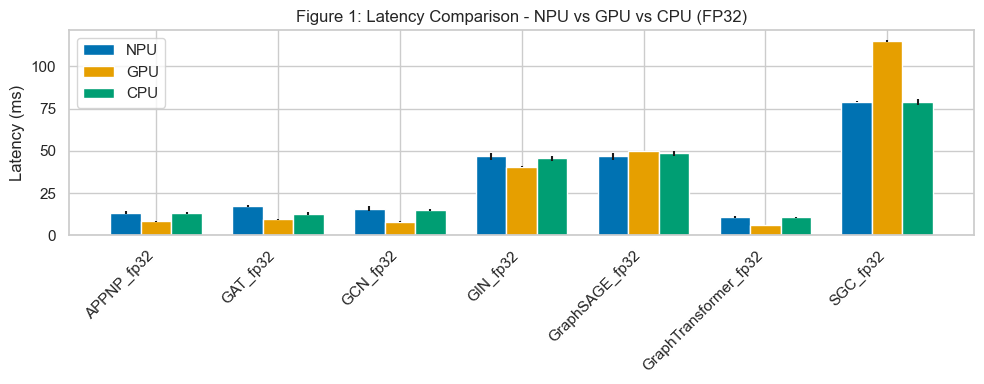

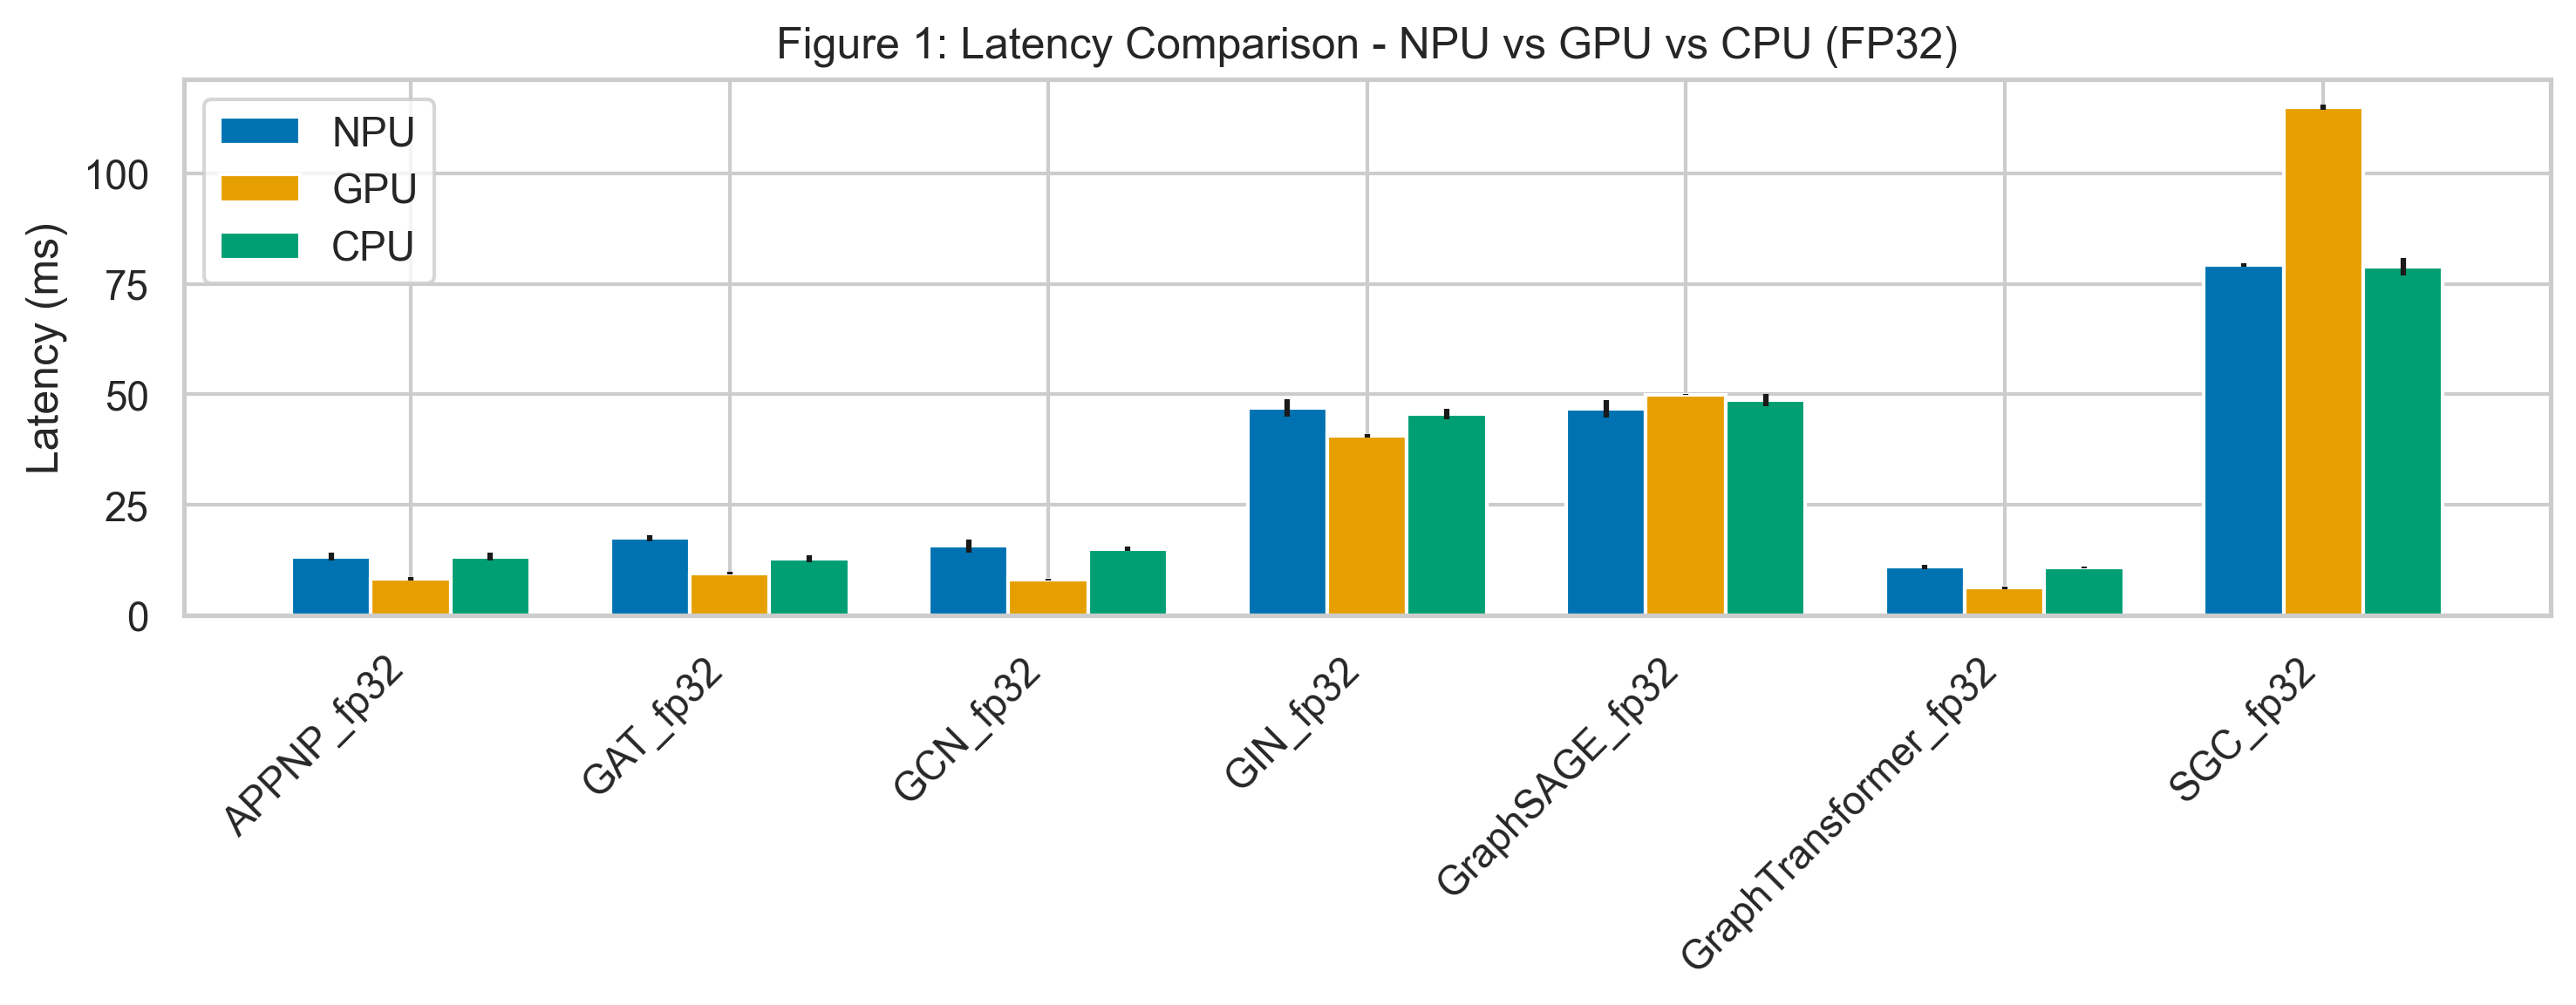

In [23]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()
    if "master_results_df" not in globals() or master_results_df.empty:
        master_path = figures_dir / "master_results.csv"
        if master_path.exists():
            master_results_df = pd.read_csv(master_path)
    if "master_results_df" not in globals() or master_results_df.empty:
        print("Data not found: master_results_df")
    else:
        df = master_results_df[master_results_df["precision"] == "fp32"]
        if df.empty:
            print("No FP32 data available.")
        else:
            mean_df = df.groupby(["model", "device"], as_index=False)["mean_ms"].mean()
            std_df = df.groupby(["model", "device"], as_index=False)["std_ms"].mean()
            mean_pivot = mean_df.pivot(index="model", columns="device", values="mean_ms").fillna(0)
            std_pivot = std_df.pivot(index="model", columns="device", values="std_ms").fillna(0)
            models = list(mean_pivot.index)
            x = np.arange(len(models))
            width = 0.25
            fig, ax = plt.subplots(figsize=(10, 4))
            for i, device in enumerate(["NPU", "GPU", "CPU"]):
                vals = mean_pivot[device] if device in mean_pivot.columns else np.zeros(len(models))
                errs = std_pivot[device] if device in std_pivot.columns else np.zeros(len(models))
                ax.bar(x + (i - 1) * width, vals, width, yerr=errs, label=device, color=IEEE_COLORS[i % len(IEEE_COLORS)])
            ax.set_title("Figure 1: Latency Comparison - NPU vs GPU vs CPU (FP32)")
            ax.set_ylabel("Latency (ms)")
            ax.set_xticks(x)
            ax.set_xticklabels(models, rotation=45, ha="right")
            ax.legend()
            plt.tight_layout()
            plt.show()
            save_figure_dual_format(fig, figures_dir / "fig1_latency_comparison")
            display(Image(filename=figures_dir / "fig1_latency_comparison.png"))
    plt.close('all')

## Stage 4-2: Figure 2 - INT8 speedup heatmap

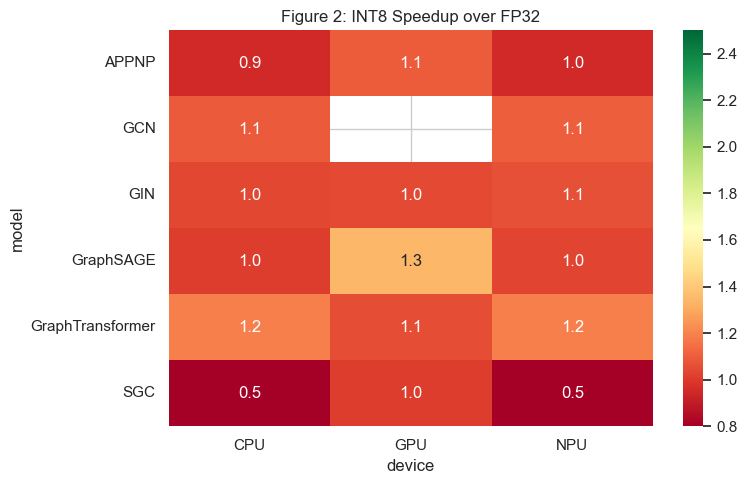

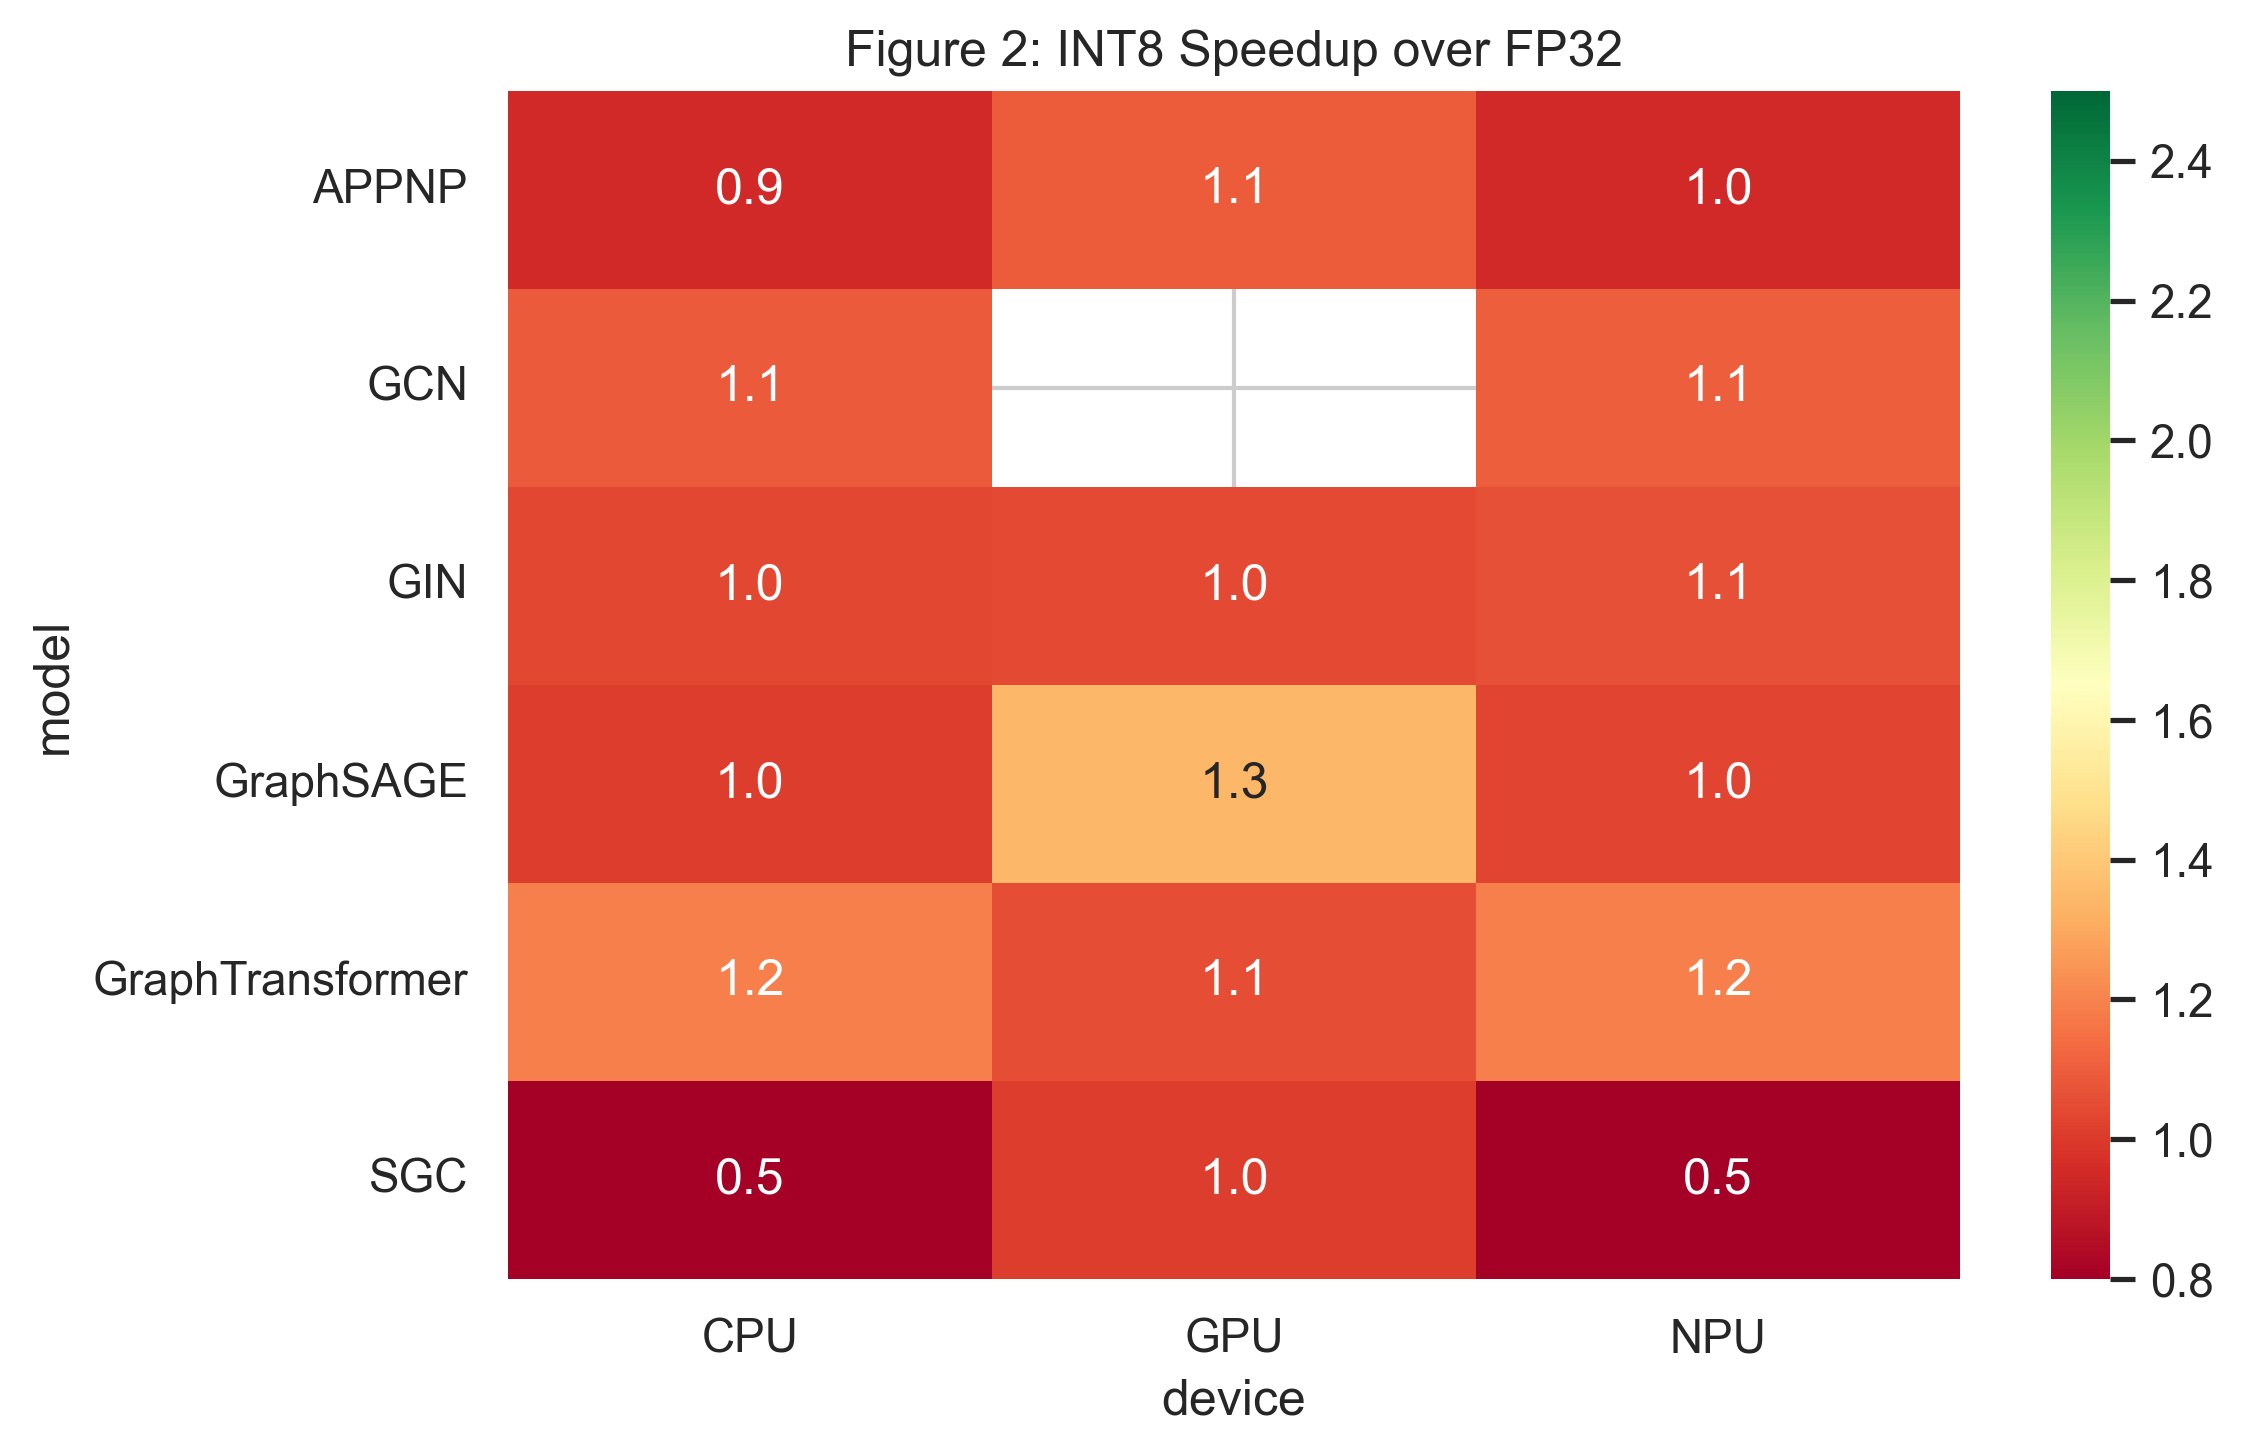

In [24]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()
    rows = []
    for path in sorted(RESULTS_DIR.glob("*/precision_gain.csv")):
        try:
            model = path.parent.name
            df = pd.read_csv(path)
            if df.empty:
                continue
            for device, grp in df.groupby("device"):
                rows.append({"model": model, "device": device, "speedup": float(grp["speedup"].mean())})
        except Exception:
            continue
    if not rows:
        print("Data not found: precision_gain.csv")
    else:
        heat_df = pd.DataFrame(rows)
        pivot = heat_df.pivot(index="model", columns="device", values="speedup")
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.heatmap(pivot, ax=ax, cmap="RdYlGn", vmin=0.8, vmax=2.5, annot=True, fmt=".1f")
        ax.set_title("Figure 2: INT8 Speedup over FP32")
        plt.tight_layout()
        plt.show()
        save_figure_dual_format(fig, figures_dir / "fig2_int8_speedup_heatmap")
        display(Image(filename=figures_dir / "fig2_int8_speedup_heatmap.png"))
    plt.close('all')

## Stage 4-3: Figure 3 - Operator breakdown

In [25]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()
    operator_mix_path = figures_dir / "operator_mix.csv"
    if operator_mix_path.exists():
        op_df = pd.read_csv(operator_mix_path)
    else:
        categories = ["SpMM/MatMul", "MLP", "Activation", "Attention", "Memory/Shape", "Other"]
        def _categorize(op_type):
            op = str(op_type)
            if op in {"MatMul", "Gemm"}:
                return "SpMM/MatMul"
            if op in {"Conv", "ConvTranspose", "DepthwiseConv"}:
                return "MLP"
            if "Attention" in op or op in {"Softmax", "LayerNormalization"}:
                return "Attention"
            if op in {"Relu", "Sigmoid", "Tanh", "Gelu"}:
                return "Activation"
            if op in {"Gather", "Scatter", "Slice", "Concat", "Transpose", "Reshape"}:
                return "Memory/Shape"
            return "Other"
        rows = []
        for model_path in sorted(MODELS_DIR.glob("*.onnx")):
            if "fp32" not in model_path.stem.lower():
                continue
            try:
                model = onnx.load(str(model_path))
                counts = {c: 0 for c in categories}
                for node in model.graph.node:
                    counts[_categorize(node.op_type)] += 1
                total = sum(counts.values()) or 1
                row = {k: (v / total) * 100 for k, v in counts.items()}
                row["model"] = model_path.stem.rsplit("_", 1)[0]
                row["category"] = get_model_category(row["model"])
                rows.append(row)
            except Exception:
                continue
        op_df = pd.DataFrame(rows)
        if not op_df.empty:
            op_df.to_csv(operator_mix_path, index=False)
    if op_df is None or op_df.empty:
        print("Data not found: operator_mix.csv")
    else:
        categories = ["SpMM/MatMul", "MLP", "Activation", "Attention", "Memory/Shape", "Other"]
        fig, ax = plt.subplots(figsize=(10, 4))
        op_df = op_df.sort_values(["category", "model"])
        x = np.arange(len(op_df))
        bottom = np.zeros(len(op_df))
        for i, cat in enumerate(categories):
            vals = op_df[cat].fillna(0).values
            ax.bar(x, vals, bottom=bottom, label=cat, color=IEEE_COLORS[i % len(IEEE_COLORS)], edgecolor="k", linewidth=0.25)
            bottom += vals
        ax.set_xticks(x)
        ax.set_xticklabels(op_df["model"], rotation=45, ha="right")
        ax.set_ylabel("Share of ONNX nodes (%)")
        ax.set_title("Figure 3: Operator Breakdown")
        ax.legend(ncol=3, fontsize=8)
        plt.tight_layout()
        plt.show()
        save_figure_dual_format(fig, figures_dir / "fig3_operator_breakdown")
        display(Image(filename=figures_dir / "fig3_operator_breakdown.png"))
    plt.close('all')

Data not found: operator_mix.csv


## Stage 4-4: Figure 4 - CPU fallback heatmap

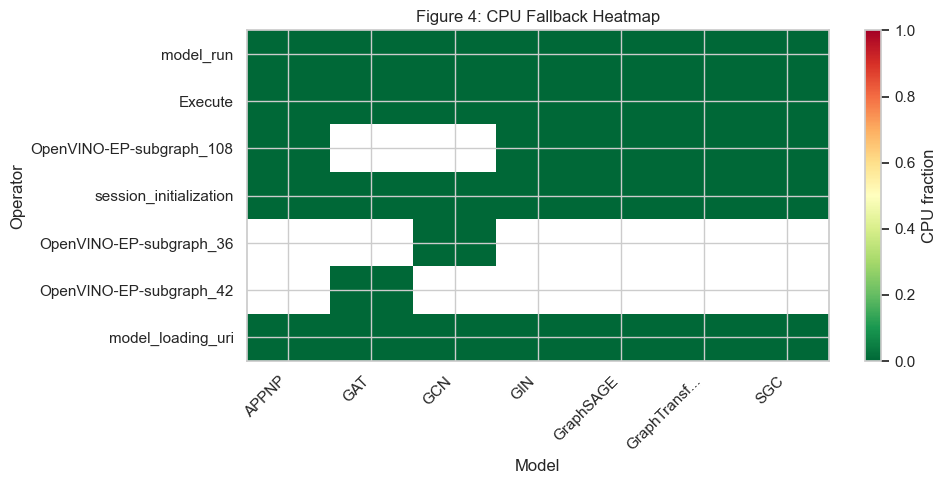

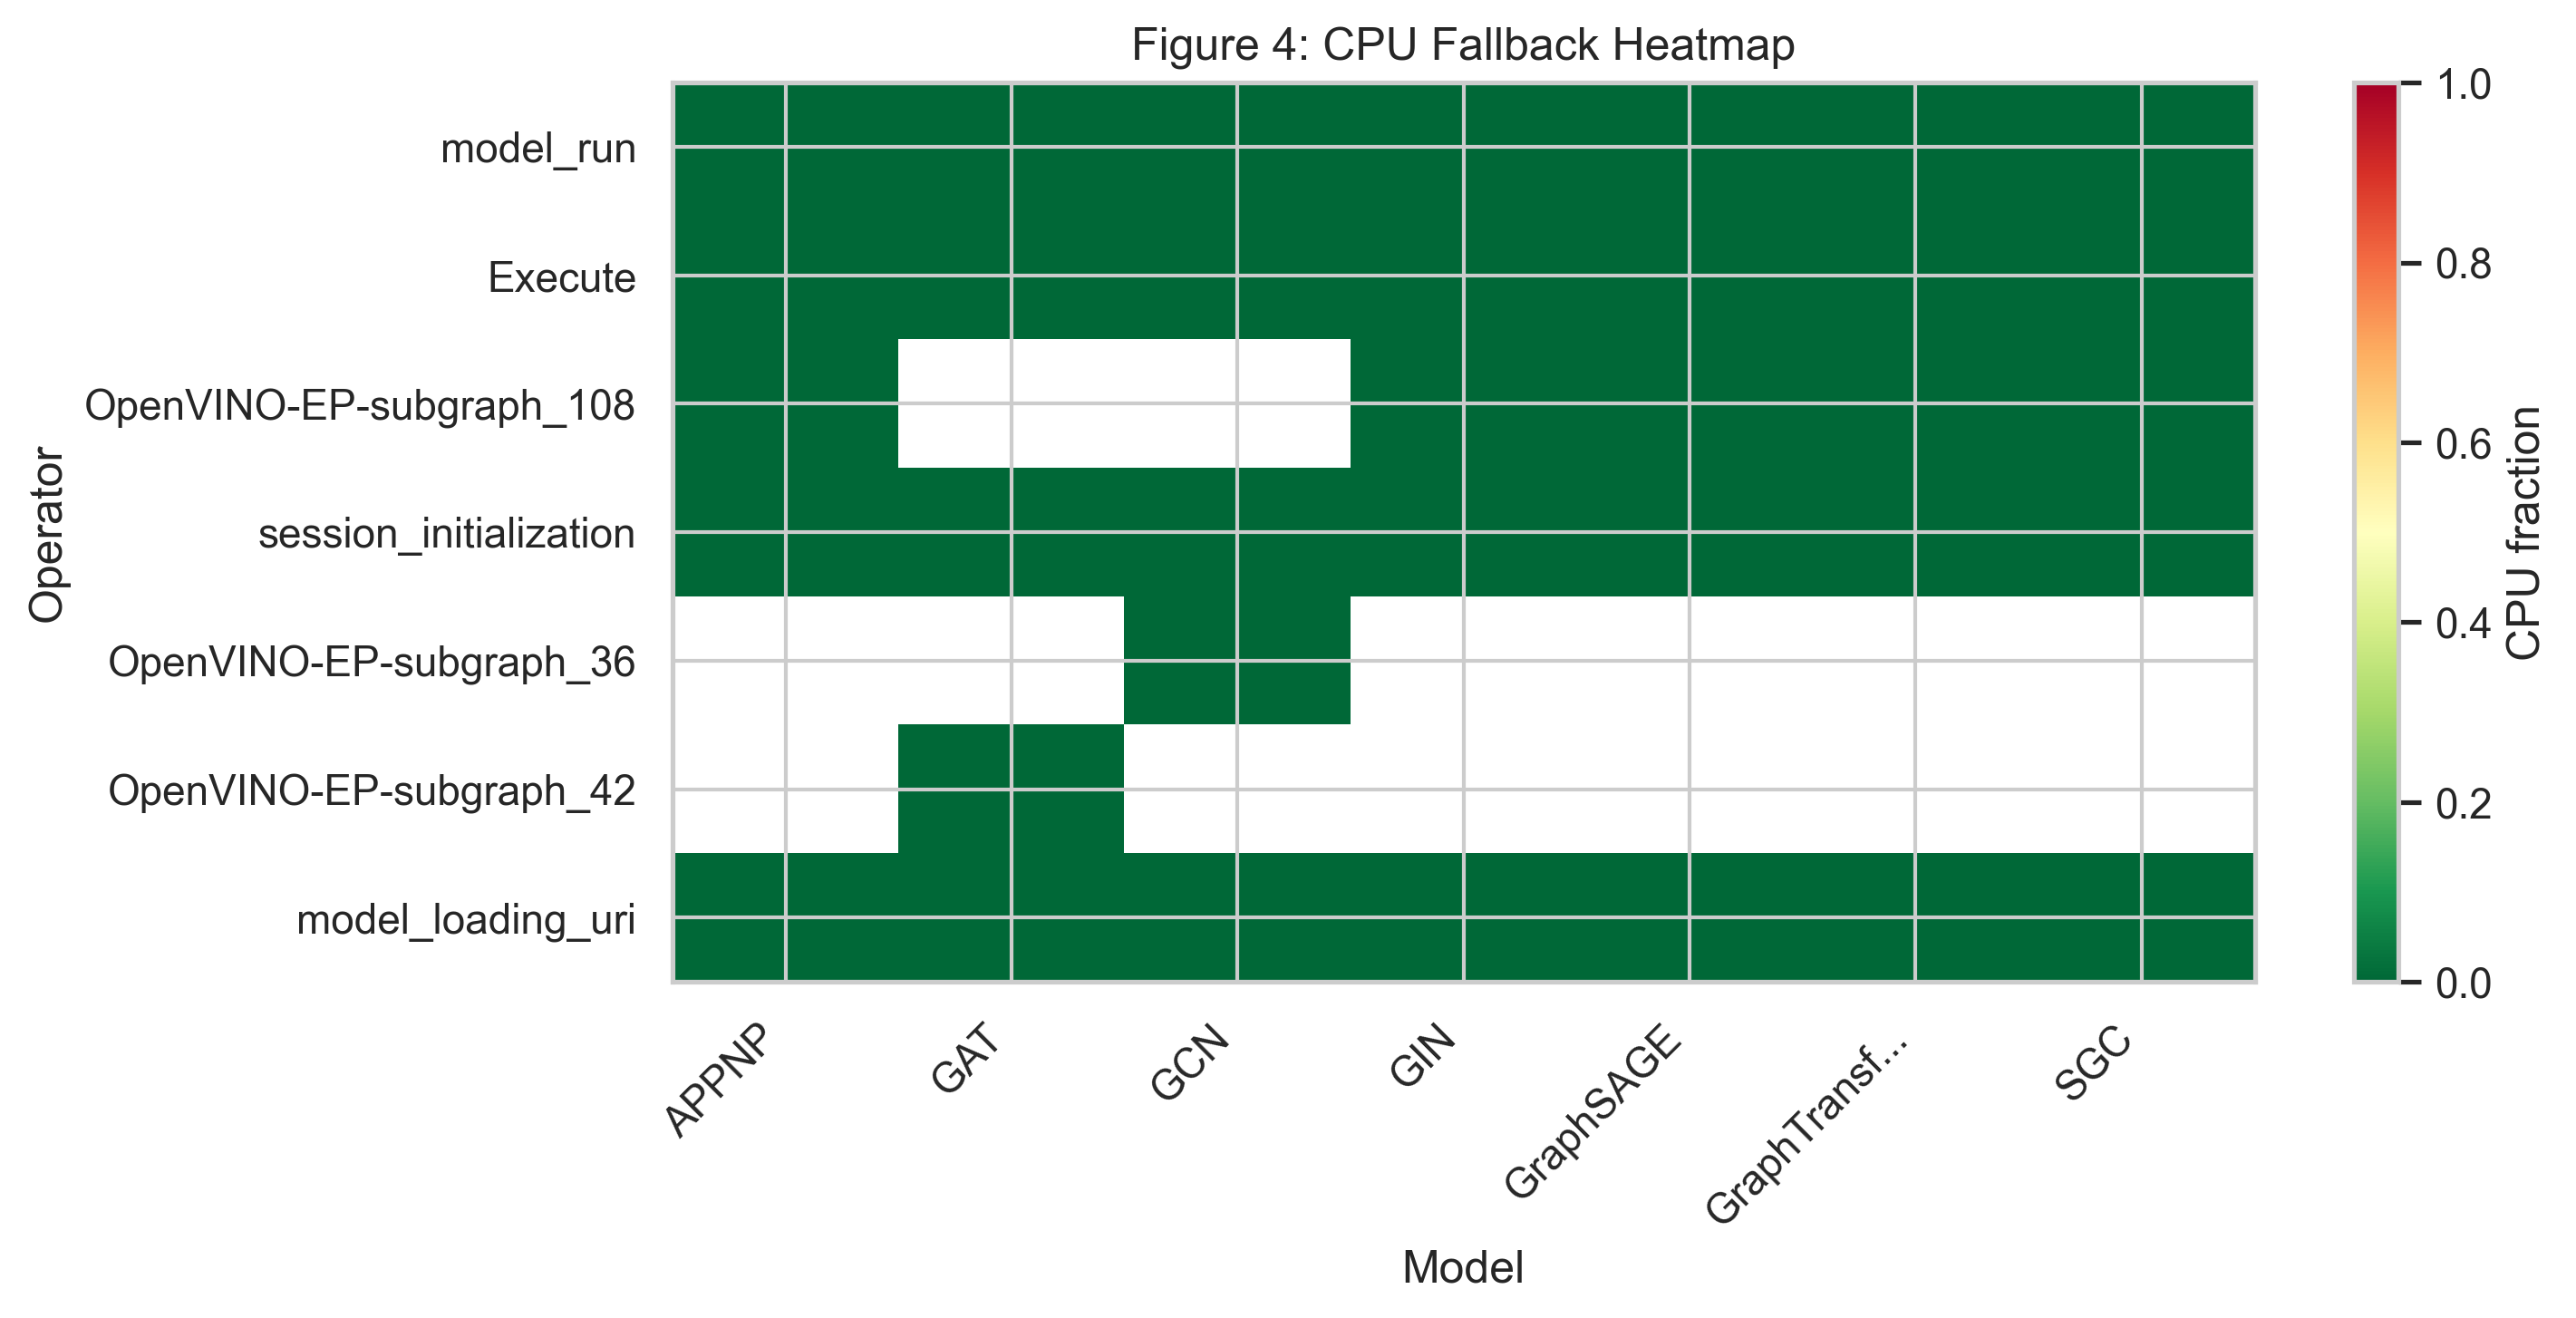

In [26]:
try:
    from analysis.ort_profile_utils import iter_operator_events, load_events
except Exception as exc:
    iter_operator_events = None
    load_events = None
    print(f"ort_profile_utils unavailable: {exc}")

if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
elif load_events is None or iter_operator_events is None:
    print("Data not found: ort_profile_utils")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()
    model_maps = {}
    op_total_time = {}
    for model_dir in [p for p in RESULTS_DIR.iterdir() if p.is_dir() and p.name not in {"figures", "density_sweep", "scaling_sweep"}]:
        traces = sorted(model_dir.glob("run_*/optimized_profiling.json"))
        if not traces:
            continue
        try:
            events = load_events(traces[-1])
            sums = {}
            for op_name, dur_us, provider, _ in iter_operator_events(events):
                op = str(op_name)
                if op not in sums:
                    sums[op] = {"cpu": 0.0, "total": 0.0}
                sums[op]["total"] += dur_us
                if "cpu" in str(provider).lower():
                    sums[op]["cpu"] += dur_us
                op_total_time[op] = op_total_time.get(op, 0.0) + dur_us
            cpu_frac = {op: v["cpu"] / v["total"] if v["total"] > 0 else 0 for op, v in sums.items()}
            model_maps[model_dir.name] = cpu_frac
        except Exception:
            continue
    if not model_maps:
        print("No profiling data found.")
    else:
        top_ops = [op for op, _ in sorted(op_total_time.items(), key=lambda x: x[1], reverse=True)[:25]]
        sorted_models = sorted(model_maps.keys())
        mat = np.full((len(top_ops), len(sorted_models)), np.nan)
        for j, model in enumerate(sorted_models):
            mp = model_maps[model]
            for i, op in enumerate(top_ops):
                if op in mp:
                    mat[i, j] = mp[op]
        fig, ax = plt.subplots(figsize=(10, 5))
        im = ax.imshow(mat, aspect="auto", vmin=0, vmax=1, cmap="RdYlGn_r")
        ax.set_xticks(range(len(sorted_models)))
        ax.set_xticklabels([shorten_label(m, 14) for m in sorted_models], rotation=45, ha="right")
        ax.set_yticks(range(len(top_ops)))
        ax.set_yticklabels([shorten_label(op, 30) for op in top_ops])
        ax.set_xlabel("Model")
        ax.set_ylabel("Operator")
        ax.set_title("Figure 4: CPU Fallback Heatmap")
        fig.colorbar(im, ax=ax, label="CPU fraction")
        plt.tight_layout()
        plt.show()
        save_figure_dual_format(fig, figures_dir / "fig4_cpu_fallback_heatmap")
        display(Image(filename=figures_dir / "fig4_cpu_fallback_heatmap.png"))
    plt.close('all')

## Stage 4-5: Figure 5 - Fusion gain vs performance

In [27]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()
    matrix_path = RESULTS_DIR / "scalability_matrix.csv"
    if matrix_path.exists():
        base_df = pd.read_csv(matrix_path)
    else:
        dfs = []
        for path in sorted(RESULTS_DIR.glob("*/scalability_matrix.csv")):
            try:
                dfs.append(pd.read_csv(path))
            except Exception:
                continue
        base_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    if base_df.empty:
        print("Data not found: scalability_matrix.csv")
    else:
        fusion_col = None
        perf_col = None
        for candidate in ["fusion_gain_ratio", "fusion_gain", "fusion_ratio"]:
            if candidate in base_df.columns:
                fusion_col = candidate
                break
        for candidate in ["latency_improvement_pct", "latency_improvement", "perf_gain_pct"]:
            if candidate in base_df.columns:
                perf_col = candidate
                break
        if fusion_col is None or perf_col is None:
            print("Required columns missing for fusion plot.")
        else:
            fig, ax = plt.subplots(figsize=(5, 4))
            base_df = _normalize_latency_df(base_df, "unknown")
            categories = base_df["model"].map(get_model_category) if "model" in base_df.columns else pd.Series(["GNN"] * len(base_df))
            marker_map = {"GNN": "o", "Transformer": "s", "CNN": "^", "Other": "D"}
            for cat in categories.unique():
                mask = categories == cat
                ax.scatter(base_df.loc[mask, fusion_col], base_df.loc[mask, perf_col], label=cat, marker=marker_map.get(cat, "o"), alpha=0.8)
            if base_df[fusion_col].notna().any() and base_df[perf_col].notna().any():
                r, p = stats.pearsonr(base_df[fusion_col].fillna(0), base_df[perf_col].fillna(0))
                ax.text(0.02, 0.98, f"r={r:.2f}, p={p:.3f}", transform=ax.transAxes, va="top")
            ax.set_xlabel("Fusion gain ratio")
            ax.set_ylabel("Latency improvement (%)")
            ax.set_title("Figure 5: Fusion Gain vs Performance")
            ax.legend(fontsize=8)
            plt.tight_layout()
            plt.show()
            save_figure_dual_format(fig, figures_dir / "fig5_fusion_gain")
            display(Image(filename=figures_dir / "fig5_fusion_gain.png"))
    plt.close('all')

Required columns missing for fusion plot.


## Stage 4-6: Figure 6 - Scaling characteristics

In [28]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()
    scaling_dir = RESULTS_DIR / "scaling_sweep"
    scaling_dir.mkdir(parents=True, exist_ok=True)
    existing = list(scaling_dir.glob("*_scaling.csv"))
    if not existing:
        models_to_run = AVAILABLE_MODELS if "AVAILABLE_MODELS" in globals() and AVAILABLE_MODELS else MODELS
        devices_to_run = active_devices if "active_devices" in globals() and active_devices else DEVICES
        for model in models_to_run:
            for device in devices_to_run:
                try:
                    cmd = [
                        sys.executable, "analysis/scaling_sweep.py",
                        "--dataset", "ogbn-arxiv",
                        "--device", device,
                        "--model", model,
                        "--dataset-root", "data",
                        "--sizes", "512,1024,2048,4096,8192",
                        "--out-dir", str(scaling_dir),
                        "--iterations", str(ITERATIONS),
                        "--repeats", str(REPEATS),
                        "--warmup", str(WARMUP)
                    ]
                    print("Running scaling sweep:", " ".join(cmd))
                    subprocess.run(cmd, check=False)
                except Exception as exc:
                    print(f"Scaling sweep failed for {model} {device}: {exc}")
        existing = list(scaling_dir.glob("*_scaling.csv"))
    if not existing:
        print("Data not found: scaling_sweep outputs")
    else:
        models = sorted({p.name.split("_")[0] for p in existing})
        devices = sorted({p.name.split("_")[1] for p in existing if "_" in p.name})
        if not models:
            print("No models found in scaling_sweep outputs.")
        else:
            fig, axes = plt.subplots(len(models), 2, figsize=(10, 4 + 1.2 * len(models)), sharex=False)
            if len(models) == 1:
                axes = np.array([axes])
            for i, model in enumerate(models):
                ax_nodes = axes[i, 0]
                ax_edges = axes[i, 1]
                for j, device in enumerate(devices):
                    path = scaling_dir / f"{model}_{device}_scaling.csv"
                    if not path.exists():
                        continue
                    df = pd.read_csv(path)
                    node_col = "num_nodes" if "num_nodes" in df.columns else ("nodes" if "nodes" in df.columns else None)
                    edge_col = "num_edges" if "num_edges" in df.columns else ("edges" if "edges" in df.columns else None)
                    lat_col = "latency_ms" if "latency_ms" in df.columns else ("mean_ms" if "mean_ms" in df.columns else None)
                    if node_col and lat_col:
                        ax_nodes.plot(df[node_col], df[lat_col], label=device, color=IEEE_COLORS[j % len(IEEE_COLORS)])
                    if edge_col and lat_col:
                        ax_edges.plot(df[edge_col], df[lat_col], label=device, color=IEEE_COLORS[j % len(IEEE_COLORS)])
                ax_nodes.set_title(f"{model} - Nodes")
                ax_nodes.set_xlabel("Nodes")
                ax_nodes.set_ylabel("Latency (ms)")
                ax_edges.set_title(f"{model} - Edges")
                ax_edges.set_xlabel("Edges")
                ax_edges.set_ylabel("Latency (ms)")
                ax_nodes.legend(fontsize=8)
            fig.suptitle("Figure 6: Scaling Characteristics", y=1.02)
            plt.tight_layout()
            plt.show()
            save_figure_dual_format(fig, figures_dir / "fig6_scaling")
            display(Image(filename=figures_dir / "fig6_scaling.png"))
    plt.close('all')

Running scaling sweep: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scaling_sweep.py --dataset ogbn-arxiv --device NPU --model APPNP --dataset-root data --sizes 512,1024,2048,4096,8192 --out-dir results\scaling_sweep --iterations 100 --repeats 3 --warmup 5
Running scaling sweep: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scaling_sweep.py --dataset ogbn-arxiv --device GPU --model APPNP --dataset-root data --sizes 512,1024,2048,4096,8192 --out-dir results\scaling_sweep --iterations 100 --repeats 3 --warmup 5
Running scaling sweep: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scaling_sweep.py --dataset ogbn-arxiv --device CPU --model APPNP --dataset-root data --sizes 512,1024,2048,4096,8192 --out-dir results\scaling_sweep --iterations 100 --repeats 3 --warmup 5
Running scaling sweep: c:\Users\yusuf\AppData\Local\Programs\Python\Python311\python.exe analysis/scaling_sweep.py --dataset ogbn-arxiv --d

## Stage 4-7: Figure 7 - Density vs NPU latency

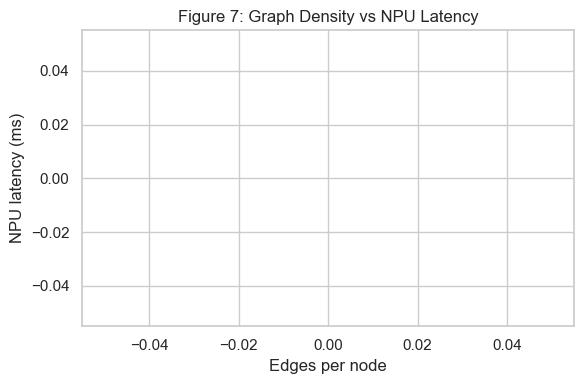

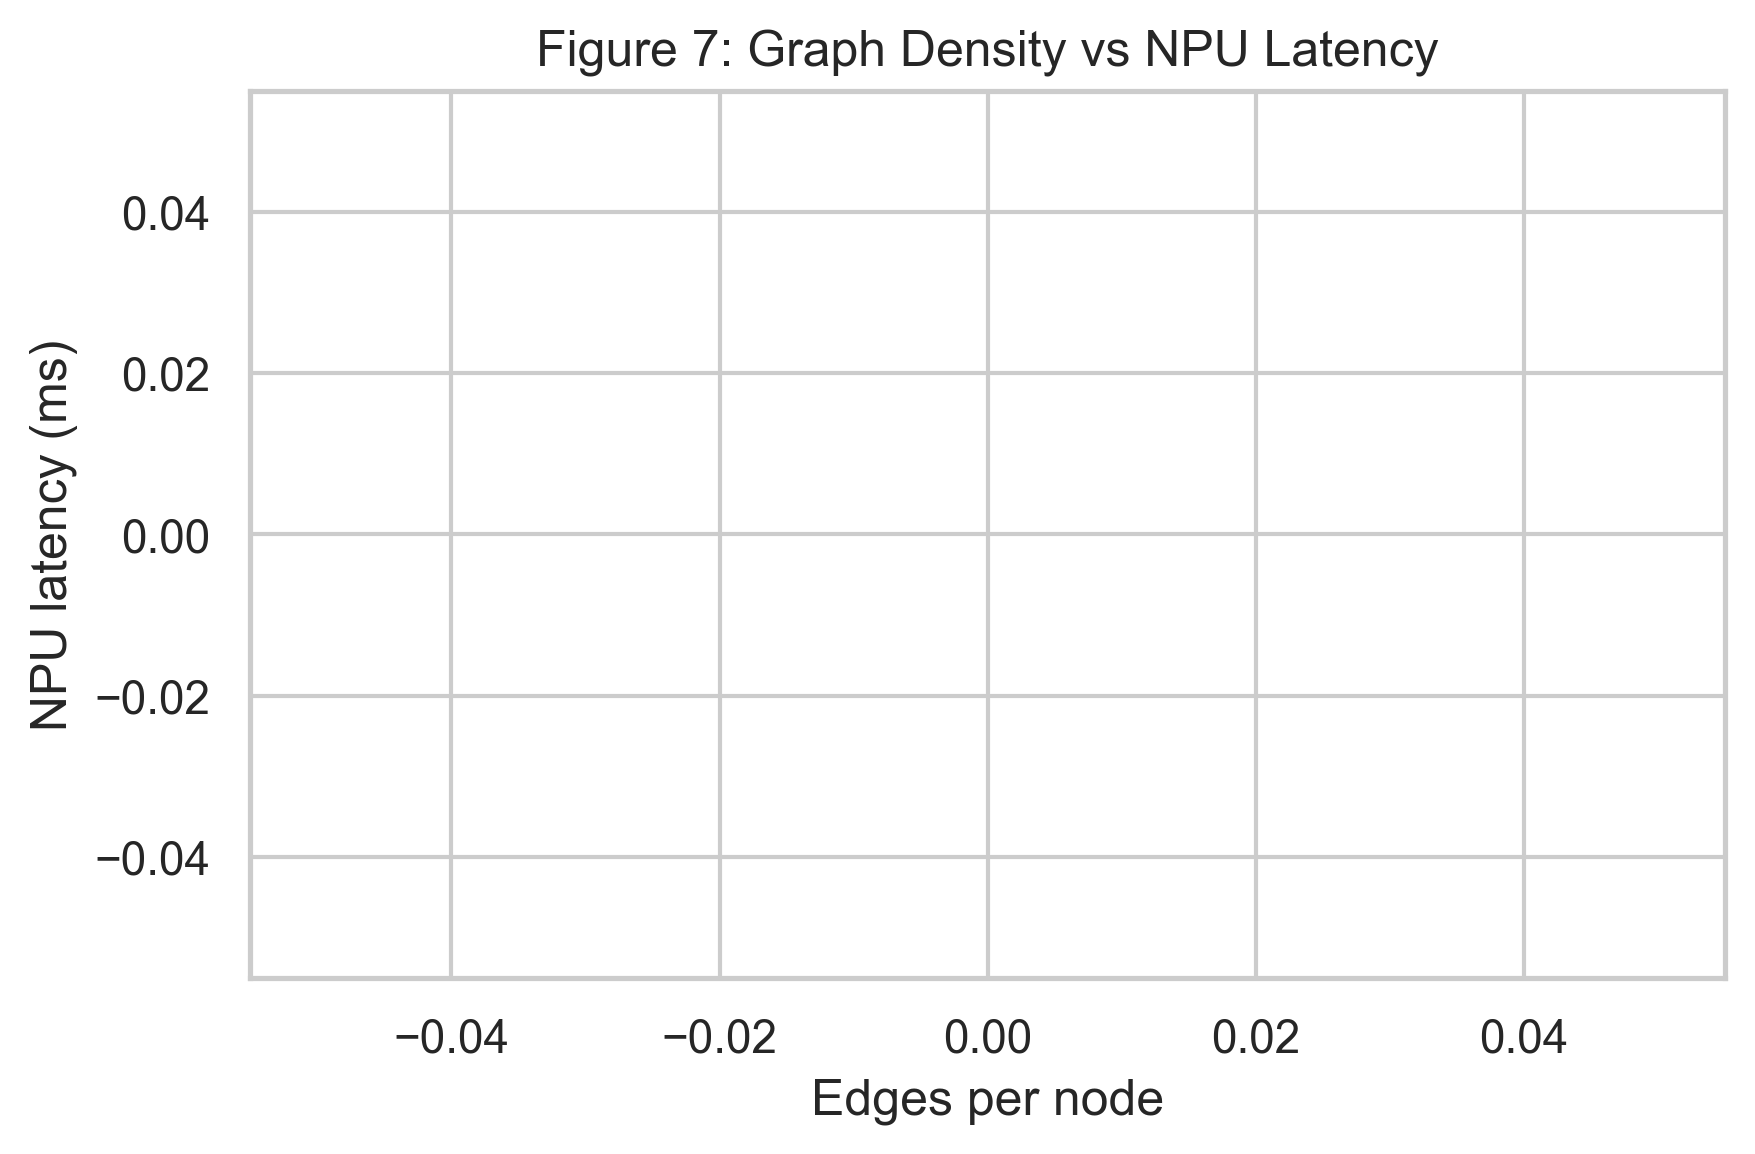

In [29]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()
    if "master_results_df" not in globals() or master_results_df.empty:
        master_path = figures_dir / "master_results.csv"
        if master_path.exists():
            master_results_df = pd.read_csv(master_path)
    if "dataset_stats" not in globals() or dataset_stats is None or dataset_stats.empty:
        dataset_stats_path = figures_dir / "dataset_stats.csv"
        if dataset_stats_path.exists():
            dataset_stats = pd.read_csv(dataset_stats_path)
    if "master_results_df" not in globals() or master_results_df.empty or "dataset_stats" not in globals() or dataset_stats.empty:
        print("Data not found: master_results_df or dataset_stats")
    else:
        npu_df = master_results_df[(master_results_df["device"] == "NPU") & (master_results_df["precision"] == "fp32")]
        npu_df = npu_df.groupby(["model", "dataset"], as_index=False)["mean_ms"].mean()
        merged = npu_df.merge(dataset_stats[["dataset", "edges_per_node"]], on="dataset", how="inner")
        if merged.empty:
            print("No matching density/latency data found.")
        else:
            fig, ax = plt.subplots(figsize=(6, 4))
            datasets = merged["dataset"].unique()
            model_markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
            model_marker_map = {m: model_markers[i % len(model_markers)] for i, m in enumerate(sorted(merged["model"].unique()))}
            for i, dataset in enumerate(datasets):
                subset = merged[merged["dataset"] == dataset]
                for _, row in subset.iterrows():
                    ax.scatter(row["edges_per_node"], row["mean_ms"], color=IEEE_COLORS[i % len(IEEE_COLORS)], marker=model_marker_map[row["model"]], alpha=0.8)
            if merged["edges_per_node"].notna().any():
                sns.regplot(x="edges_per_node", y="mean_ms", data=merged, scatter=False, ax=ax, color="black")
                r, p = stats.pearsonr(merged["edges_per_node"], merged["mean_ms"])
                ax.text(0.02, 0.98, f"r={r:.2f}, p={p:.3f}", transform=ax.transAxes, va="top")
            ax.set_xlabel("Edges per node")
            ax.set_ylabel("NPU latency (ms)")
            ax.set_title("Figure 7: Graph Density vs NPU Latency")
            plt.tight_layout()
            plt.show()
            save_figure_dual_format(fig, figures_dir / "fig7_density_vs_latency")
            display(Image(filename=figures_dir / "fig7_density_vs_latency.png"))
    plt.close('all')

## Stage 4-8: Figure 8 - Energy consumption

In [30]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()
    rows = []
    component_rows = []
    for path in sorted(RESULTS_DIR.glob("*/energy.json")):
        model = path.parent.name
        try:
            payload = json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            continue
        if payload.get("error"):
            rows.append({"model": model, "device": "NPU", "total_mJ": np.nan, "error": "socwatch_not_found"})
            rows.append({"model": model, "device": "GPU", "total_mJ": np.nan, "error": "socwatch_not_found"})
            rows.append({"model": model, "device": "CPU", "total_mJ": np.nan, "error": "socwatch_not_found"})
            continue
        for device in DEVICES:
            key = f"{device}_fp32"
            entry = payload.get(key)
            if isinstance(entry, dict):
                rows.append({"model": model, "device": device, "total_mJ": entry.get("total_mJ"), "error": None})
            else:
                rows.append({"model": model, "device": device, "total_mJ": np.nan, "error": "missing"})
        npu_entry = payload.get("NPU_fp32")
        if isinstance(npu_entry, dict):
            component_rows.append({
                "model": model,
                "ia_mW": npu_entry.get("ia_mW"),
                "gt_mW": npu_entry.get("gt_mW"),
                "dram_mW": npu_entry.get("dram_mW")
            })
    energy_df = pd.DataFrame(rows)
    comp_df = pd.DataFrame(component_rows)
    if energy_df.empty or not energy_df["total_mJ"].notna().any():
        print("SoCWatch data not found - energy plot skipped")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        ax_left, ax_right = axes
        models = sorted(energy_df["model"].unique())
        x = np.arange(len(models))
        width = 0.25
        for i, device in enumerate(["NPU", "GPU", "CPU"]):
            vals = []
            colors = []
            for model in models:
                row = energy_df[(energy_df["model"] == model) & (energy_df["device"] == device)]
                val = row["total_mJ"].values[0] if not row.empty else np.nan
                vals.append(val if val is not None else np.nan)
                colors.append(IEEE_COLORS[i % len(IEEE_COLORS)] if np.isfinite(val) else "#BBBBBB")
            ax_left.bar(x + (i - 1) * width, vals, width, label=device, color=colors)
        for idx, model in enumerate(models):
            subset = energy_df[energy_df["model"] == model]
            if not subset["total_mJ"].notna().any():
                ax_left.text(x[idx], 0, "SoCWatch N/A", ha="center", va="bottom", rotation=90, fontsize=8)
        ax_left.set_title("Energy per Inference (FP32)")
        ax_left.set_ylabel("Total energy (mJ)")
        ax_left.set_xticks(x)
        ax_left.set_xticklabels(models, rotation=45, ha="right")
        ax_left.legend()
        if comp_df.empty:
            ax_right.text(0.5, 0.5, "SoCWatch N/A", ha="center", va="center")
            ax_right.axis("off")
        else:
            comp_df = comp_df.set_index("model").reindex(models)
            ia = comp_df["ia_mW"].fillna(0)
            gt = comp_df["gt_mW"].fillna(0)
            dram = comp_df["dram_mW"].fillna(0)
            ax_right.bar(x, ia, label="IA", color=IEEE_COLORS[0])
            ax_right.bar(x, gt, bottom=ia, label="GT", color=IEEE_COLORS[1])
            ax_right.bar(x, dram, bottom=ia + gt, label="DRAM", color=IEEE_COLORS[2])
            ax_right.set_title("NPU Power Components (mW)")
            ax_right.set_xticks(x)
            ax_right.set_xticklabels(models, rotation=45, ha="right")
            ax_right.legend(fontsize=8)
        fig.suptitle("Figure 8: Energy Consumption per Inference (SoCWatch)", y=1.02)
        plt.tight_layout()
        plt.show()
        save_figure_dual_format(fig, figures_dir / "fig8_energy_comparison")
        display(Image(filename=figures_dir / "fig8_energy_comparison.png"))
    plt.close('all')

SoCWatch data not found - energy plot skipped


## Output inventory

In [31]:
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    if figures_dir.exists():
        files = sorted([p for p in figures_dir.iterdir() if p.suffix.lower() in {".png", ".svg", ".csv"}])
        print("Figures directory outputs:")
        for p in files:
            size_kb = p.stat().st_size / 1024
            print(f"- {p.name}: {size_kb:.1f} KB")
    else:
        print("results/figures not found.")
    print("")
    model_dirs = [p for p in RESULTS_DIR.iterdir() if p.is_dir() and p.name not in {"figures", "density_sweep", "scaling_sweep"}]
    for model_dir in sorted(model_dirs):
        files = list(model_dir.rglob("*"))
        files = [p for p in files if p.is_file()]
        total_size = sum(p.stat().st_size for p in files)
        print(f"{model_dir.name}: {len(files)} files, {total_size / 1024:.1f} KB")
    if "RUN_START_TIME" in globals():
        elapsed_s = time.time() - RUN_START_TIME
        print(f"Elapsed time: {elapsed_s / 60:.1f} min")

Figures directory outputs:
- comparison_table.csv: 1.2 KB
- fig1_latency_comparison.png: 142.8 KB
- fig1_latency_comparison.svg: 45.3 KB
- fig2_int8_speedup_heatmap.png: 102.0 KB
- fig2_int8_speedup_heatmap.svg: 45.5 KB
- fig4_cpu_fallback_heatmap.png: 170.3 KB
- fig4_cpu_fallback_heatmap.svg: 51.0 KB
- fig7_density_vs_latency.png: 61.2 KB
- fig7_density_vs_latency.svg: 34.5 KB
- master_results.csv: 5.7 KB
- summary_stats.csv: 2.5 KB

APPNP: 43 files, 2488.4 KB
bert-tiny: 0 files, 0.0 KB
ChebNet: 2 files, 1.3 KB
DiffPool: 2 files, 1.3 KB
EdgeCNN: 2 files, 1.3 KB
efficientnet-b0: 0 files, 0.0 KB
GAT: 25 files, 1375.6 KB
GATv2: 0 files, 0.0 KB
GCN: 46 files, 2486.8 KB
GCNII: 2 files, 1.3 KB
GIN: 43 files, 2480.9 KB
GPS: 2 files, 1.3 KB
GraphSAGE: 43 files, 2498.7 KB
GraphTransformer: 43 files, 2471.7 KB
MinCutPool: 2 files, 1.3 KB
mobilenetv2: 0 files, 0.0 KB
MPNN: 0 files, 0.0 KB
PNA: 2 files, 1.3 KB
resnet50: 0 files, 0.0 KB
SGC: 43 files, 2543.1 KB
vit-tiny: 0 files, 0.0 KB
Elapsed ti